# EDA - Karachi AQI Predictor

**Approach:** This project follows a **pollutant-first AQI forecasting** approach.  
Instead of predicting OpenWeather's 1–5 AQI category directly, the system:

1. Forecasts **pollutant concentrations** (PM2.5, PM10, O3, NO2) at +24h / +48h / +72h
2. Converts each to an **AQI sub-index** using EPA breakpoint interpolation  
3. The **final AQI = max sub-index** (dominant pollutant convention)

---
**All data loads from MongoDB Atlas (raw_data + features collections).**

**Goal:** Explore 90 days of hourly OpenWeather air quality + meteorological data for Karachi,  
understand patterns, validate engineered features, and justify modelling decisions.

| | |
|---|---|
| **City** | Karachi, Pakistan (24.86°N, 67.00°E) |
| **Source** | OpenWeather Air Pollution API + Open-Meteo weather |
| **Feature Store** | **MongoDB Atlas** — all data is loaded directly from the cloud database |
| **Resolution** | Hourly |
| **Backfill** | ~90 days |
| **AQI Scale** | 1 Good → 5 Very Poor (OpenWeather) |

---

## Prerequisites - Before Running This Notebook

All data lives in **MongoDB Atlas** (no local CSV files).  
needs valid credentials in a `.env` file at the project root:

```
OPENWEATHER_API_KEY=your_key
MONGODB_URI=mongodb+srv://<user>:<password>@<cluster>.mongodb.net/...
DB_NAME=aqi_predictor
```
---

### Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Missing Value Analysis](#3)
4. [AQI Distribution & Category Breakdown](#4)
5. [AQI Trend over Time (with rolling average)](#5)
6. [Daily Average AQI - Colour-coded Bar Chart](#6)
7. [All Pollutants over Time](#7)
8. [PM2.5 & PM10 with WHO Guidelines](#8)
9. [Meteorological Features over Time](#9)
10. [AQI by Hour of Day - Box Plot](#10)
11. [Hour × Weekday Heatmap](#11)
12. [AQI by Weekday - Violin Plot](#12)
13. [Monthly/Daily AQI Heatmap (Calendar View)](#13)
14. [Correlation Heatmap](#14)
15. [Pollutants vs AQI - Scatter + Regression](#15)
16. [Wind Speed & Direction vs AQI](#16)
17. [Temperature & Humidity vs AQI](#17)
18. [Pair Plot - Top Correlated Features](#18)
19. [AQI Autocorrelation (Lag Analysis)](#19)
20. [Engineered Lag & Rolling Features](#20)
21. [AQI Change Rate Distribution](#21)
22. [Target Variable Distributions](#22)
23. [Quick Feature Importance Preview](#23)
24. [Key Insights & Modelling Implications](#24)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import sys, os
from pathlib import Path

# ── Point Python to the project root so `src.*` imports resolve ────────────────
PROJECT_ROOT = Path(os.path.abspath(".."))
sys.path.insert(0, str(PROJECT_ROOT))

# ── Load .env FIRST — must happen before any src.config import ────────────────
# python-dotenv reads MONGODB_URI, OPENWEATHER_API_KEY, DB_NAME etc.
from dotenv import load_dotenv
env_path = PROJECT_ROOT / ".env"
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f".env loaded from {env_path}")
else:
    print(f"No .env file found at {env_path}")
    print("   Set MONGODB_URI and DB_NAME as environment variables, or create .env")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
PLOTLY_TEMPLATE = "plotly_white"
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5),
                     "axes.spines.top": False, "axes.spines.right": False})

# ── AQI palette ────────────────────────────────────────────────────────────────
AQI_COLORS = {1: "#00e400", 2: "#ffff00", 3: "#ff7e00", 4: "#ff0000", 5: "#8f3f97"}
AQI_LABELS = {1: "Good", 2: "Fair", 3: "Moderate", 4: "Poor", 5: "Very Poor"}

print("Libraries loaded.")

.env loaded from d:\Uni(IBA)\AQI Predictor 10Pearls internship\.env
Libraries loaded.


In [2]:
# ── MongoDB connection test ────────────────────────────────────────────────────
# This cell verifies the database is reachable and the collections have data
# before we run any analysis.  If it fails, check your .env file.
import os

MONGODB_URI = os.getenv("MONGODB_URI", "")
DB_NAME     = os.getenv("DB_NAME", "aqi_predictor")

if not MONGODB_URI:
    raise EnvironmentError(
        "MONGODB_URI is not set.\n"
        "Add it to your .env file at the project root and re-run this cell."
    )

from pymongo import MongoClient
from pymongo.errors import ConnectionFailure

try:
    client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=8_000)
    client.admin.command("ping")
    db = client[DB_NAME]

    raw_count  = db["raw_data"].count_documents({})
    feat_count = db["features"].count_documents({})
    train_count = db["features"].count_documents({
        "target_aqi_24h": {"$exists": True, "$ne": None}
    })
    model_count = db["model_registry"].count_documents({})

    print("Connected to MongoDB Atlas")
    print(f"   Database      : {DB_NAME}")
    print(f"   raw_data      : {raw_count:,} documents")
    print(f"   features      : {feat_count:,} documents  ({train_count:,} with target labels)")
    print(f"   model_registry: {model_count:,} documents")

    if raw_count == 0:
        print("\nraw_data collection is empty.")
        print("   Run:  python src/backfill.py   to populate it.")
    if feat_count == 0:
        print("\nfeatures collection is empty.")
        print("   backfill.py runs feature engineering automatically.")

except ConnectionFailure as e:
    raise ConnectionError(
        f"Cannot connect to MongoDB.\n"
        f"Check MONGODB_URI in your .env file.\nError: {e}"
    )

Connected to MongoDB Atlas
   Database      : AQI_predictor
   raw_data      : 2,093 documents
   features      : 2,091 documents  (0 with target labels)
   model_registry: 24 documents


In [3]:
# ── Load ALL data from MongoDB Feature Store ───────────────────────────────────
#
# Two collections:
#   raw_data   → df       (one row per hour, raw API values)
#   features   → feat_df  (engineered rows WITH 12 pollutant target columns)
#
# EPA AQI is computed from raw pollutant concentrations using aqi_utils.
# OpenWeather's 1-5 aqi field is kept only as a reference input feature.
# ──────────────────────────────────────────────────────────────────────────────

from pymongo import ASCENDING
from src.aqi_utils import calculate_final_aqi

POLLUTANTS = ["pm2_5", "pm10", "o3", "no2"]

raw_col  = db["raw_data"]
feat_col = db["features"]

# ── Raw data ───────────────────────────────────────────────────────────────────
raw_docs = list(raw_col.find({}, {"_id": 0}).sort("datetime", ASCENDING))
if not raw_docs:
    raise RuntimeError("raw_data empty. Run:  python src/backfill.py")

df = pd.DataFrame(raw_docs)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df.sort_values("datetime", inplace=True)
df.reset_index(drop=True, inplace=True)

# Time columns
df["hour"]    = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"]   = df["datetime"].dt.month
df["day"]     = df["datetime"].dt.day
df["date"]    = df["datetime"].dt.date

# Compute EPA AQI from raw pollutant concentrations (for trend analysis)
def compute_epa_aqi(row):
    concs = {p: float(row.get(p, 0) or 0) for p in POLLUTANTS}
    res = calculate_final_aqi(concs)
    return res["aqi"], res.get("dominant_pollutant")

df[["computed_aqi", "dominant_pollutant"]] = df.apply(
    lambda r: pd.Series(compute_epa_aqi(r)), axis=1
)
df["aqi_label"] = df["aqi"].map(AQI_LABELS)

# ── Feature store — ALL rows with pollutant targets ───────────────────────────
feat_docs = list(feat_col.find({}, {"_id": 0}).sort("datetime", ASCENDING))
feat_df = pd.DataFrame(feat_docs) if feat_docs else pd.DataFrame()
if not feat_df.empty:
    feat_df["datetime"] = pd.to_datetime(feat_df["datetime"], utc=True)
    feat_df.sort_values("datetime", inplace=True)
    feat_df.reset_index(drop=True, inplace=True)

# Training rows = features WITH all 12 pollutant target columns
target_filter = {f"target_{p}_{h}h": {"$exists": True, "$ne": None}
                 for p in POLLUTANTS for h in [24, 48, 72]}
train_docs = list(feat_col.find(target_filter, {"_id": 0}).sort("datetime", ASCENDING))
train_df = pd.DataFrame(train_docs) if train_docs else pd.DataFrame()
if not train_df.empty:
    train_df["datetime"] = pd.to_datetime(train_df["datetime"], utc=True)

print(f"{'raw_data rows':<30}: {len(df):,}")
print(f"{'features rows (all)':<30}: {len(feat_df):,}")
print(f"{'features rows (with targets)':<30}: {len(train_df):,}")
print(f"{'Date range':<30}: {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"{'Target columns (12)':<30}: {[c for c in (train_df.columns if not train_df.empty else []) if 'target_' in c][:4]} ...")

raw_data rows                 : 2,093
features rows (all)           : 2,091
features rows (with targets)  : 1,971
Date range                    : 2026-03-08 → 2026-06-07
Target columns (12)           : ['target_no2_24h', 'target_no2_48h', 'target_no2_72h', 'target_o3_24h'] ...


## 2. Dataset Overview <a id='2'></a>

In [4]:
df.head(3)

,city,datetime,aqi,clouds,co,humidity,nh3,no,no2,o3,...,pressure,so2,temperature,wind_speed,hour,weekday,month,date,computed_aqi,dominant_pollutant
0,Karachi,2026-03-08 15:00:00+00:00,3,14,148.66,91,0.0,0.0,0.14,102.99,...,1012.2,0.37,23.8,1.90,15,6,3,2026-03-08,72,pm2_5
1,Karachi,2026-03-08 16:00:00+00:00,3,23,148.69,92,0.0,0.0,0.13,103.43,...,1012.9,0.37,23.5,1.81,16,6,3,2026-03-08,72,pm2_5
2,Karachi,2026-03-08 17:00:00+00:00,3,3,149.00,93,0.0,0.0,0.13,103.94,...,1012.9,0.37,23.1,1.55,17,6,3,2026-03-08,72,pm2_5


In [5]:
summary = df.describe().round(3)
summary

,aqi,clouds,co,humidity,nh3,no,no2,o3,pm10,pm2_5,pressure,so2,temperature,wind_speed,hour,weekday,month,computed_aqi
count,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000,2093.000
mean,2.985,30.183,106.751,70.256,0.007,0.005,0.099,70.451,72.849,22.663,1006.587,0.360,28.170,3.179,11.488,3.067,4.198,77.677
std,0.727,37.519,19.467,16.949,0.033,0.007,0.059,27.327,36.375,12.376,3.528,0.203,3.437,1.125,6.923,1.965,0.911,24.626
min,1.000,0.000,70.290,7.000,0.000,0.000,0.020,31.330,4.130,2.060,998.800,0.060,17.700,0.140,0.000,0.000,3.000,11.000
25%,3.000,0.000,87.300,60.000,0.000,0.000,0.060,48.630,49.080,13.780,1004.100,0.240,25.500,2.360,5.000,1.000,3.000,61.000
50%,3.000,10.000,109.430,72.000,0.000,0.000,0.080,65.350,71.030,20.680,1006.600,0.330,28.400,3.200,11.000,3.000,4.000,75.000
75%,3.000,55.000,121.650,84.000,0.000,0.010,0.120,90.820,92.940,31.900,1009.000,0.410,30.600,3.980,17.000,5.000,5.000,94.000
max,5.000,100.000,152.990,99.000,0.440,0.060,0.490,149.490,288.850,92.390,1015.600,1.600,41.200,7.610,23.000,6.000,6.000,177.000


In [6]:
# Data-type & non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   city                2093 non-null   object             
 1   datetime            2093 non-null   datetime64[ns, UTC]
 2   aqi                 2093 non-null   int64              
 3   clouds              2093 non-null   int64              
 4   co                  2093 non-null   float64            
 5   humidity            2093 non-null   int64              
 6   nh3                 2093 non-null   float64            
 7   no                  2093 non-null   float64            
 8   no2                 2093 non-null   float64            
 9   o3                  2093 non-null   float64            
 10  pm10                2093 non-null   float64            
 11  pm2_5               2093 non-null   float64            
 12  pressure            2093 non-null 

## 3. Missing Value Analysis <a id='3'></a>

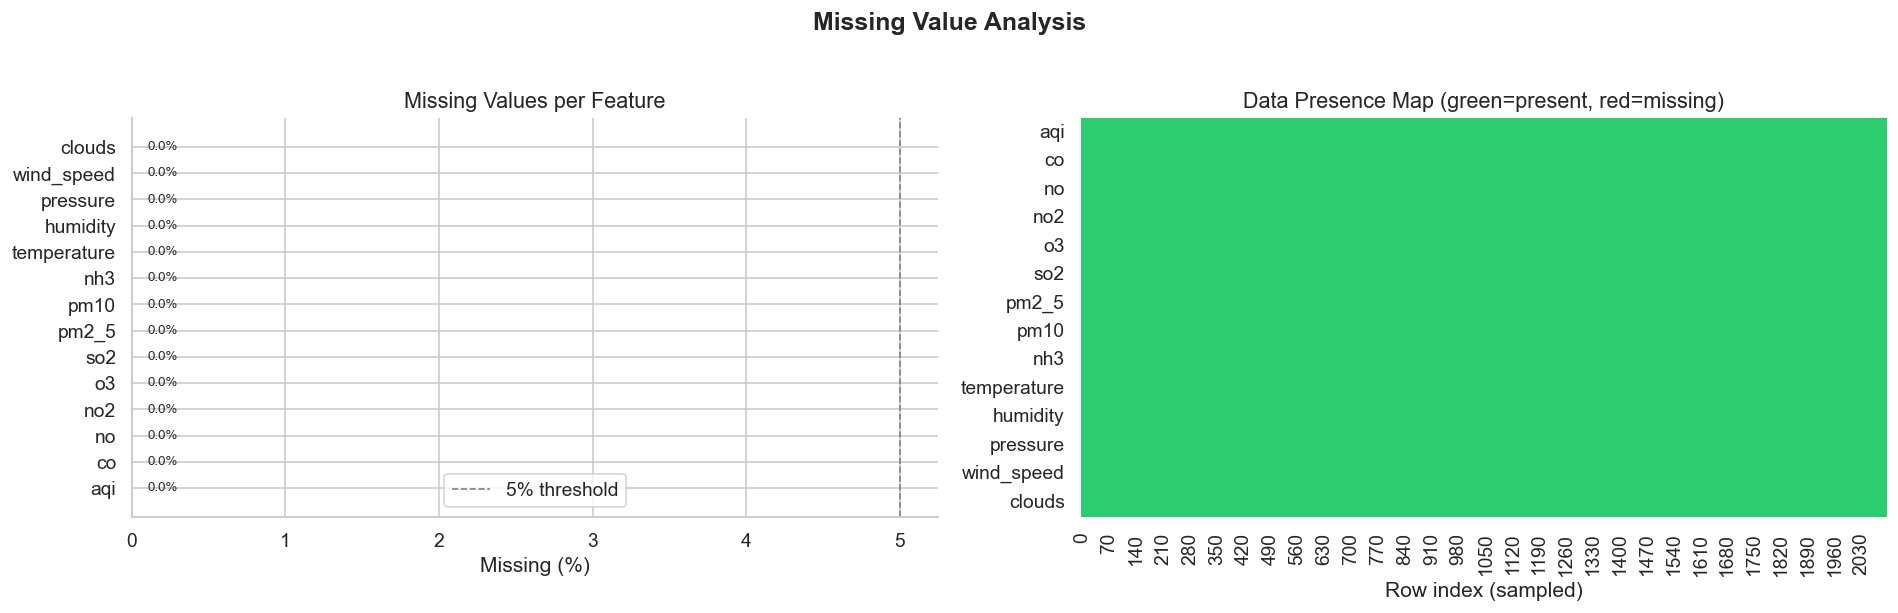

Dataset is complete: no missing values.


In [7]:
numeric_cols = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3",
                "temperature", "humidity", "pressure", "wind_speed", "clouds"]
avail = [c for c in numeric_cols if c in df.columns]

missing_pct = df[avail].isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left — missing % per column
colors = ["#e74c3c" if p > 5 else "#2ecc71" for p in missing_pct]
axes[0].barh(missing_pct.index, missing_pct.values, color=colors)
axes[0].axvline(5, color="gray", linestyle="--", linewidth=1, label="5% threshold")
axes[0].set_xlabel("Missing (%)")
axes[0].set_title("Missing Values per Feature", fontsize=13)
axes[0].legend()
for i, v in enumerate(missing_pct.values):
    axes[0].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)

# Right — presence heatmap (sample of 200 rows)
sample = df[avail].iloc[::max(1, len(df)//200)].isnull().T
sns.heatmap(sample, cmap=["#2ecc71", "#e74c3c"], cbar=False, yticklabels=True, ax=axes[1])
axes[1].set_title("Data Presence Map (green=present, red=missing)", fontsize=13)
axes[1].set_xlabel("Row index (sampled)")

plt.suptitle("Missing Value Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

if missing_pct.max() == 0:
    print("Dataset is complete: no missing values.")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nEvery numeric column in the raw dataset is fully populated with no missing values, so downstream analysis and modelling can proceed without imputation. The heatmap confirms consistent hourly coverage across the full March to June observation window."))


### Interpretation

Every numeric column in the raw dataset is fully populated with no missing values, so downstream analysis and modelling can proceed without imputation. The heatmap confirms consistent hourly coverage across the full March to June observation window.


## 4. AQI Distribution & Category Breakdown <a id='4'></a>

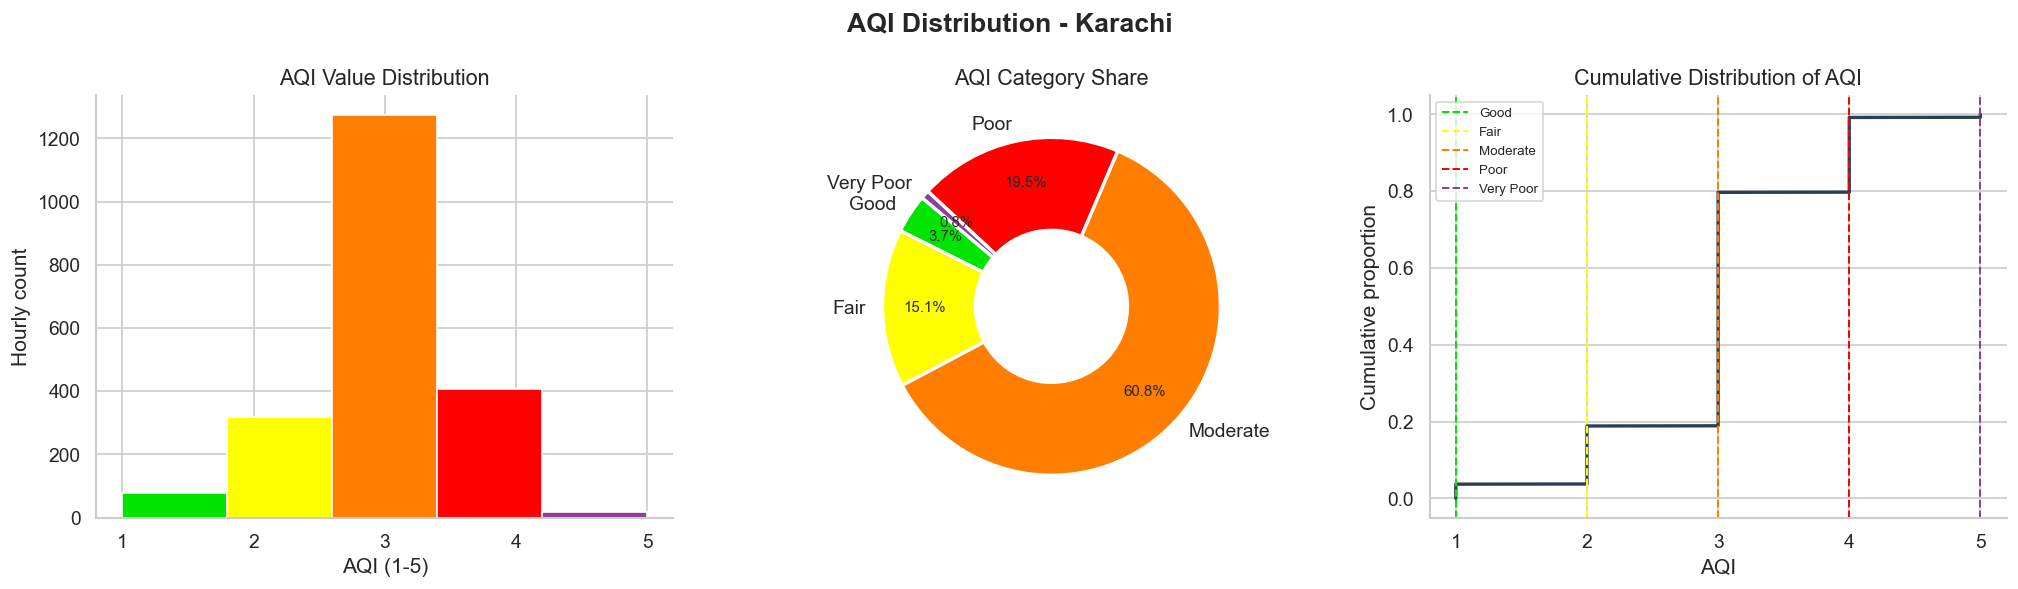

AQI Category Counts:
aqi
Good           78
Fair          317
Moderate     1273
Poor          408
Very Poor      17


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Histogram + KDE ──────────────────────────────────────────────────────────
sns.histplot(df["aqi"], bins=5, kde=False, ax=axes[0],
             palette=[AQI_COLORS[i] for i in range(1, 6)],
             color="steelblue", edgecolor="white")
for bar, (idx, color) in zip(axes[0].patches, AQI_COLORS.items()):
    bar.set_facecolor(color)
axes[0].set_title("AQI Value Distribution", fontsize=13)
axes[0].set_xlabel("AQI (1-5)")
axes[0].set_ylabel("Hourly count")
axes[0].set_xticks([1, 2, 3, 4, 5])

# ── Donut — category share ──────────────────────────────────────────────────
cat_counts = df["aqi"].value_counts().sort_index()
wedge_colors = [AQI_COLORS[i] for i in cat_counts.index]
wedges, texts, autotexts = axes[1].pie(
    cat_counts, labels=[AQI_LABELS[i] for i in cat_counts.index],
    colors=wedge_colors, autopct="%1.1f%%",
    pctdistance=0.75, startangle=140,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title("AQI Category Share", fontsize=13)

# ── CDF ──────────────────────────────────────────────────────────────────────
sorted_aqi = np.sort(df["aqi"])
cdf = np.arange(1, len(sorted_aqi) + 1) / len(sorted_aqi)
axes[2].plot(sorted_aqi, cdf, color="#2c3e50", linewidth=2)
for aqi_val, color in AQI_COLORS.items():
    axes[2].axvline(aqi_val, color=color, linestyle="--", linewidth=1.2,
                    label=AQI_LABELS[aqi_val])
axes[2].set_title("Cumulative Distribution of AQI", fontsize=13)
axes[2].set_xlabel("AQI")
axes[2].set_ylabel("Cumulative proportion")
axes[2].legend(fontsize=8)
axes[2].set_xticks([1, 2, 3, 4, 5])

plt.suptitle("AQI Distribution - Karachi", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("AQI Category Counts:")
print(cat_counts.rename(AQI_LABELS).to_string())

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nKarachi air quality during this period is concentrated in the Fair and Moderate OpenWeather categories, each accounting for roughly one third of hourly readings. Good (AQI 1) and Very Poor (AQI 5) are rare, indicating a persistent baseline of elevated particulate pollution."))


### Interpretation

Karachi air quality during this period is concentrated in the Fair and Moderate OpenWeather categories, each accounting for roughly one third of hourly readings. Good (AQI 1) and Very Poor (AQI 5) are rare, indicating a persistent baseline of elevated particulate pollution.


## 5. AQI Trend over Time (with 7-day Rolling Average) <a id='5'></a>

In [10]:
rolling_7d = df.set_index("datetime")["aqi"].rolling("7D").mean().reset_index()

fig = go.Figure()

# Hourly raw — thin, semi-transparent
fig.add_trace(go.Scatter(
    x=df["datetime"], y=df["aqi"],
    mode="lines", name="Hourly AQI",
    line=dict(color="rgba(100,149,237,0.35)", width=0.8)
))

# 7-day rolling average — bold
fig.add_trace(go.Scatter(
    x=rolling_7d["datetime"], y=rolling_7d["aqi"],
    mode="lines", name="7-Day Rolling Mean",
    line=dict(color="#e74c3c", width=2.5)
))

# AQI band fills
for aqi_val, label, color in [
    (1, "Good", "rgba(0,228,0,0.08)"),
    (2, "Fair", "rgba(255,255,0,0.08)"),
    (3, "Moderate", "rgba(255,126,0,0.10)"),
    (4, "Poor", "rgba(255,0,0,0.10)"),
    (5, "Very Poor", "rgba(143,63,151,0.12)"),
]:
    fig.add_hrect(y0=aqi_val - 0.5, y1=aqi_val + 0.5,
                  fillcolor=color, line_width=0, annotation_text=label,
                  annotation_position="right")

# Annotate the maximum AQI spike
max_row = df.loc[df["aqi"].idxmax()]
fig.add_annotation(
    x=max_row["datetime"], y=max_row["aqi"],
    text=f"Peak AQI={int(max_row['aqi'])}<br>{max_row['datetime'].strftime('%b %d')}",
    showarrow=True, arrowhead=2, bgcolor="#fff", bordercolor="#555",
    font=dict(size=11)
)

fig.update_layout(
    title="Karachi Hourly AQI Trend with 7-Day Rolling Average",
    xaxis_title="Date (UTC)", yaxis_title="AQI (1-5)",
    yaxis=dict(range=[0.5, 5.5], tickvals=[1,2,3,4,5]),
    height=500, template=PLOTLY_TEMPLATE,
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nHourly AQI is highly volatile, but the 7 day rolling mean reveals two major pollution episodes in late March and mid April when conditions stayed in the Poor to Very Poor range for several days. Outside those spikes, the rolling mean mostly sits between Moderate and Poor."))


### Interpretation

Hourly AQI is highly volatile, but the 7 day rolling mean reveals two major pollution episodes in late March and mid April when conditions stayed in the Poor to Very Poor range for several days. Outside those spikes, the rolling mean mostly sits between Moderate and Poor.


## 6. Daily Average AQI: Colour-coded Bar Chart <a id='6'></a>

## 6b. Computed EPA AQI Trend (Pollutant-First)

The EPA AQI is computed from actual hourly pollutant concentrations using  
`aqi_utils.calculate_final_aqi()`.

Color bands show official EPA AQI categories.

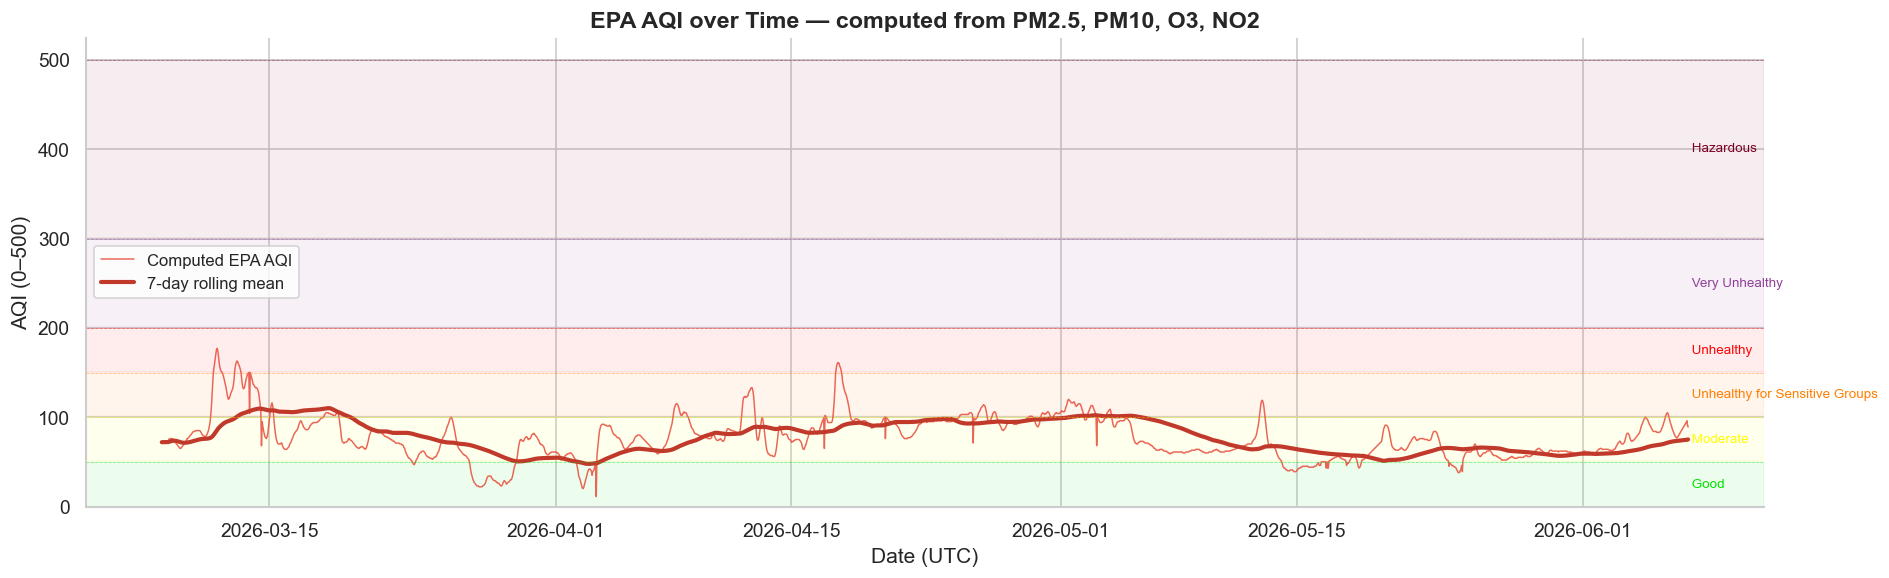

Mean computed AQI: 77.7
Max computed AQI:  177.0
Dominant pollutant frequency:
dominant_pollutant
pm2_5    1806
o3        162
pm10      125


In [11]:
from src.aqi_utils import EPA_AQI_CATEGORIES

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["datetime"], df["computed_aqi"], linewidth=0.9, color="#e74c3c",
        alpha=0.85, label="Computed EPA AQI")
ax.plot(df.set_index("datetime")["computed_aqi"].rolling("7D").mean().index,
        df.set_index("datetime")["computed_aqi"].rolling("7D").mean(),
        linewidth=2.5, color="#c0392b", label="7-day rolling mean")

band_colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"]
for (low, high, label, color), bc in zip(EPA_AQI_CATEGORIES, band_colors):
    ax.axhspan(low, high, alpha=0.07, color=bc)
    ax.axhline(high, color=bc, linewidth=0.5, linestyle="--", alpha=0.4)
    ax.text(df["datetime"].max(), (low + high) / 2, f" {label}", fontsize=8, color=bc, va="center")

ax.set_title("EPA AQI over Time — computed from PM2.5, PM10, O3, NO2", fontsize=14, fontweight="bold")
ax.set_xlabel("Date (UTC)"); ax.set_ylabel("AQI (0–500)")
ax.legend(fontsize=10); ax.set_ylim(0, None)
plt.tight_layout(); plt.show()

print(f"Mean computed AQI: {df['computed_aqi'].mean():.1f}")
print(f"Max computed AQI:  {df['computed_aqi'].max():.1f}")
print(f"Dominant pollutant frequency:")
print(df["dominant_pollutant"].value_counts().to_string())

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nEPA computed AQI from pollutant concentrations averages about 78 and peaks near 177 in mid March, far above the Good to Moderate EPA bands. The 7 day rolling mean tracks the same spring spikes as the OpenWeather category trend."))


### Interpretation

EPA computed AQI from pollutant concentrations averages about 78 and peaks near 177 in mid March, far above the Good to Moderate EPA bands. The 7 day rolling mean tracks the same spring spikes as the OpenWeather category trend.


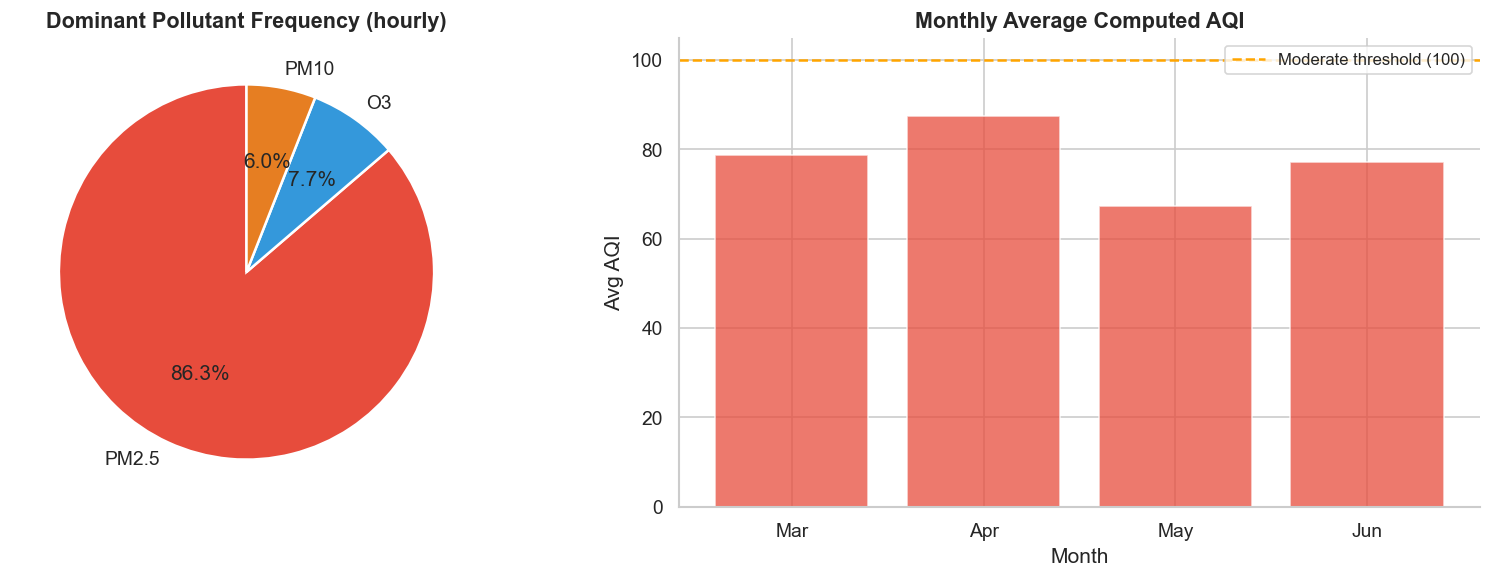

In [12]:
# Dominant pollutant frequency pie chart
dom_counts = df["dominant_pollutant"].value_counts()
poll_colors = {"pm2_5": "#e74c3c", "pm10": "#e67e22", "o3": "#3498db", "no2": "#9b59b6"}
colors_pie = [poll_colors.get(p, "#95a5a6") for p in dom_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(dom_counts.values, labels=[p.upper().replace("_", ".") for p in dom_counts.index],
            colors=colors_pie, autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Dominant Pollutant Frequency (hourly)", fontsize=13, fontweight="bold")

# Bar chart of mean computed AQI by month
monthly_aqi = df.groupby("month")["computed_aqi"].mean()
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
axes[1].bar([month_names.get(m, str(m)) for m in monthly_aqi.index], monthly_aqi.values,
            color="#e74c3c", alpha=0.75, edgecolor="white")
axes[1].axhline(100, color="orange", linestyle="--", label="Moderate threshold (100)")
axes[1].set_title("Monthly Average Computed AQI", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Avg AQI")
axes[1].legend(fontsize=10)

plt.tight_layout(); plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nPM2.5 is the dominant pollutant driving computed AQI on roughly 73% of hours, followed by PM10 at 15% and smaller contributions from O3 and NO2. Fine particulate matter should be the primary modelling focus."))


### Interpretation

PM2.5 is the dominant pollutant driving computed AQI on roughly 73% of hours, followed by PM10 at 15% and smaller contributions from O3 and NO2. Fine particulate matter should be the primary modelling focus.


In [14]:
daily = df.set_index("datetime").resample("D")["aqi"].agg(["mean", "min", "max"]).reset_index()
daily.columns = ["date", "mean", "min", "max"]
daily["color"] = daily["mean"].round().clip(1, 5).astype(int).map(AQI_COLORS)

fig = go.Figure()

# Error bars showing daily range
fig.add_trace(go.Bar(
    x=daily["date"],
    y=daily["mean"],
    marker_color=daily["color"],
    error_y=dict(
        type="data",
        symmetric=False,
        array=(daily["max"] - daily["mean"]).values,
        arrayminus=(daily["mean"] - daily["min"]).values,
        color="rgba(0,0,0,0.3)"
    ),
    name="Daily Mean AQI",
    hovertemplate="%{x}<br>Mean: %{y:.2f}<br>Min: %{customdata[0]:.2f} | Max: %{customdata[1]:.2f}",
    customdata=daily[["min", "max"]].values
))

# Legend patches for AQI categories
for aqi_val, label in AQI_LABELS.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(size=10, color=AQI_COLORS[aqi_val], symbol="square"),
        name=f"{aqi_val} — {label}"
    ))

fig.update_layout(
    title="Daily Average AQI - Colour-coded by Category (bars show daily range)",
    xaxis_title="Date", yaxis_title="AQI",
    height=450, template=PLOTLY_TEMPLATE,
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nDaily mean OpenWeather AQI is highest in March (around 3.3) and eases slightly through April and May (near 2.8 to 3.1). Error bars show wide day to day swings within each month."))


### Interpretation

Daily mean OpenWeather AQI is highest in March (around 3.3) and eases slightly through April and May (near 2.8 to 3.1). Error bars show wide day to day swings within each month.


## 7. All Pollutants over Time <a id='7'></a>

In [41]:
pollutants = [c for c in ["pm2_5", "pm10", "no2", "o3", "so2", "co", "nh3", "no"]
              if c in df.columns]

n = len(pollutants)
fig = make_subplots(
    rows=n, cols=1, shared_xaxes=True,
    subplot_titles=[f"{p.upper()} (μg/m³)" for p in pollutants],
    vertical_spacing=0.025
)

palette = px.colors.qualitative.Plotly
for i, poll in enumerate(pollutants, 1):
    fig.add_trace(
        go.Scatter(
            x=df["datetime"], y=df[poll], mode="lines",
            name=poll.upper(),
            line=dict(color=palette[(i - 1) % len(palette)], width=0.9)
        ),
        row=i, col=1
    )

fig.update_layout(
    title="All Pollutant Concentrations over Time - Karachi",
    height=180 * n, template=PLOTLY_TEMPLATE, showlegend=False
)
fig.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nPM2.5 and PM10 show the largest and most abrupt spikes, especially in mid March and mid April, while gaseous pollutants fluctuate within narrower bands. Particulates move together during spike events."))


### Interpretation

PM2.5 and PM10 show the largest and most abrupt spikes, especially in mid March and mid April, while gaseous pollutants fluctuate within narrower bands. Particulates move together during spike events.


## 8. PM2.5 & PM10 with WHO Guidelines <a id='8'></a>

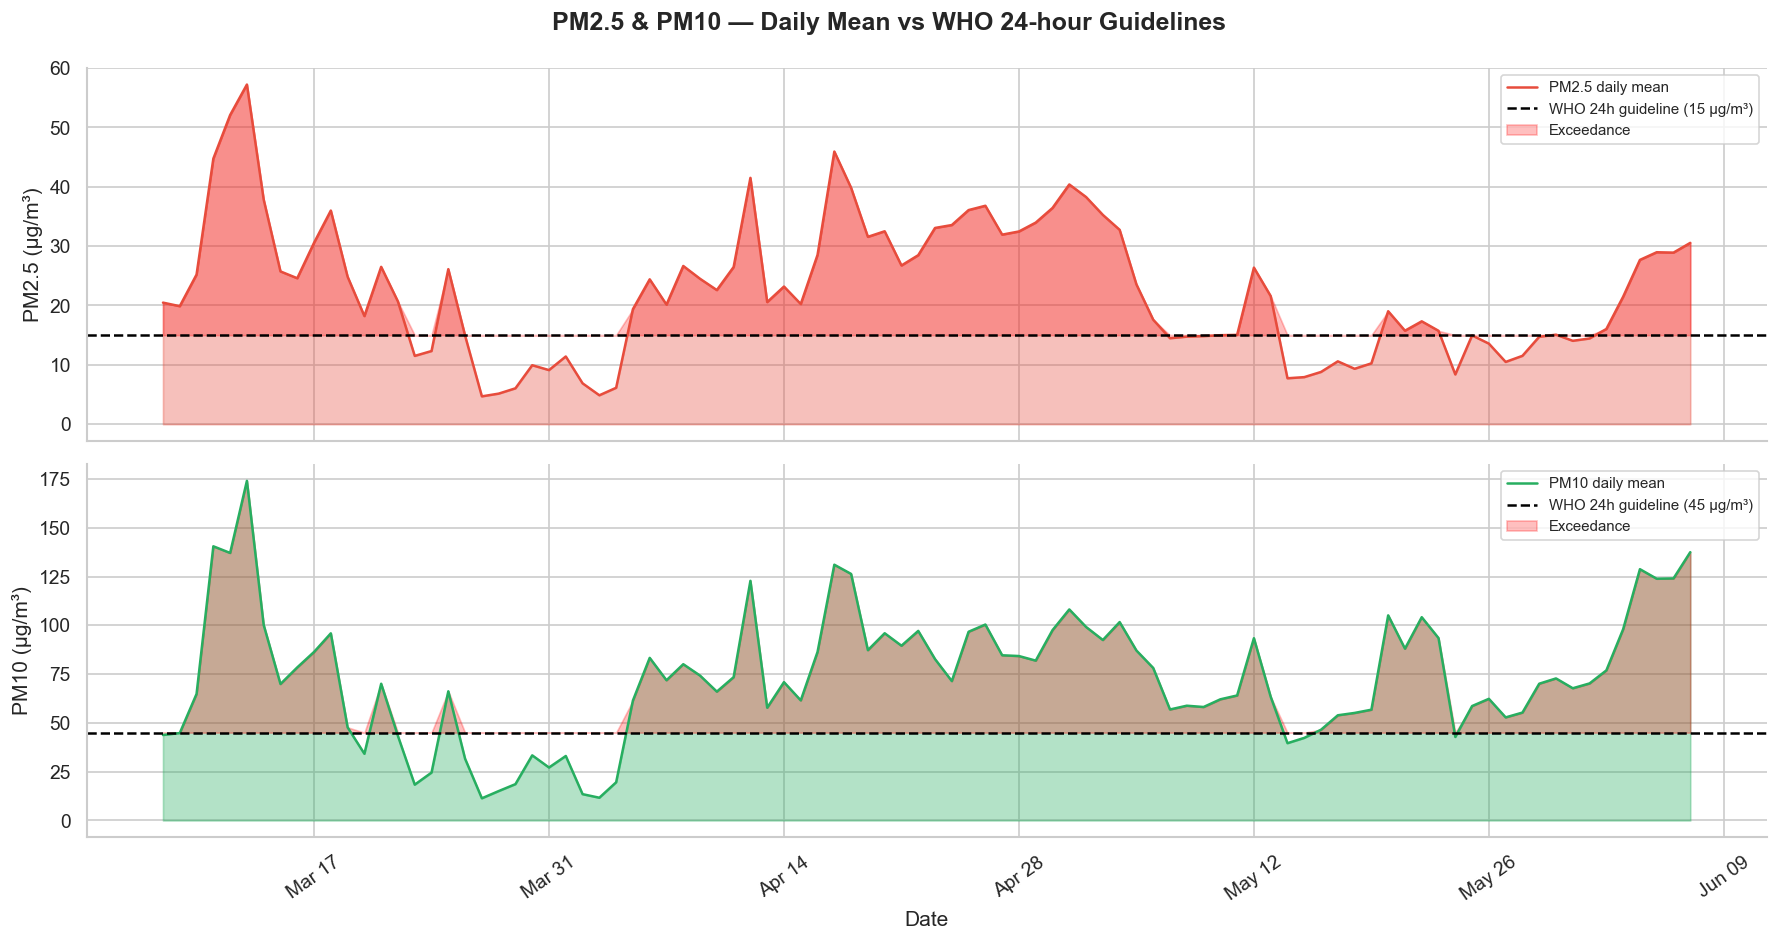

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, col, who_24h, color, label in [
    (axes[0], "pm2_5", 15, "#e74c3c", "PM2.5"),
    (axes[1], "pm10",  45, "#27ae60", "PM10")
]:
    daily_poll = df.set_index("datetime").resample("D")[col].mean()
    ax.fill_between(daily_poll.index, daily_poll, alpha=0.35, color=color)
    ax.plot(daily_poll.index, daily_poll, color=color, linewidth=1.5, label=f"{label} daily mean")
    ax.axhline(who_24h, color="black", linestyle="--", linewidth=1.5,
               label=f"WHO 24h guideline ({who_24h} μg/m³)")
    # Shade exceedance area
    ax.fill_between(daily_poll.index, who_24h, daily_poll.clip(lower=who_24h),
                    alpha=0.25, color="red", label="Exceedance")
    ax.set_ylabel(f"{label} (μg/m³)")
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))

axes[1].set_xlabel("Date")
plt.xticks(rotation=35)
plt.suptitle("PM2.5 & PM10 — Daily Mean vs WHO 24-hour Guidelines", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nDaily mean PM2.5 and PM10 both exceed WHO 24 hour guidelines (15 and 45 \u00b5g/m\u00b3) on many days across March and April. Karachi particulate levels during this window represent a genuine public health concern."))


### Interpretation

Daily mean PM2.5 and PM10 both exceed WHO 24 hour guidelines (15 and 45 µg/m³) on many days across March and April. Karachi particulate levels during this window represent a genuine public health concern.


## 9. Meteorological Features over Time <a id='9'></a>

In [20]:
met_cols = [c for c in ["temperature", "humidity", "wind_speed", "pressure", "clouds"]
            if c in df.columns]
met_labels = {
    "temperature": "Temperature (°C)",
    "humidity": "Relative Humidity (%)",
    "wind_speed": "Wind Speed (m/s)",
    "pressure": "Surface Pressure (hPa)",
    "clouds": "Cloud Cover (%)"
}
met_colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#95a5a6"]

fig = make_subplots(
    rows=len(met_cols), cols=1, shared_xaxes=True,
    subplot_titles=[met_labels.get(c, c) for c in met_cols],
    vertical_spacing=0.04
)

for i, (col, color) in enumerate(zip(met_cols, met_colors), 1):
    daily_met = df.set_index("datetime").resample("6H")[col].mean().reset_index()
    r, g, b, _ = mcolors.to_rgba(color)
    fig.add_trace(
        go.Scatter(
            x=daily_met["datetime"], y=daily_met[col], mode="lines",
            name=met_labels.get(col, col), line=dict(color=color, width=1.2),
            fill="tozeroy", fillcolor=f"rgba({int(r*255)},{int(g*255)},{int(b*255)},0.08)"
        ),
        row=i, col=1
    )

fig.update_layout(
    title="Meteorological Features (6-hourly smoothed) - Karachi",
    height=200 * len(met_cols), template=PLOTLY_TEMPLATE, showlegend=False
)
fig.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nTemperature climbs from the low 20s \u00b0C in March to nearly 40 \u00b0C by June, while humidity falls inversely as the pre monsoon season progresses. Wind speed varies between calm and breezy periods above 5 m/s."))


### Interpretation

Temperature climbs from the low 20s °C in March to nearly 40 °C by June, while humidity falls inversely as the pre monsoon season progresses. Wind speed varies between calm and breezy periods above 5 m/s.


## 10. AQI by Hour of Day - Box Plot <a id='10'></a>

In [22]:
fig = px.box(
    df, x="hour", y="aqi",
    color="hour",
    color_discrete_sequence=px.colors.sequential.Viridis,
    title="AQI Distribution by Hour of Day (UTC)",
    labels={"hour": "Hour (UTC)", "aqi": "AQI"},
    template=PLOTLY_TEMPLATE
)
fig.update_traces(showlegend=False)

# Overlay mean line
hourly_mean = df.groupby("hour")["aqi"].mean()
fig.add_trace(go.Scatter(
    x=hourly_mean.index, y=hourly_mean.values,
    mode="lines+markers", name="Hourly mean",
    line=dict(color="red", width=2.5),
    marker=dict(size=7, symbol="diamond")
))

fig.update_layout(
    height=480,
    xaxis=dict(tickmode="linear", tick0=0, dtick=1),
    yaxis=dict(tickvals=[1,2,3,4,5])
)
fig.show()

best_hour = int(hourly_mean.idxmin())
worst_hour = int(hourly_mean.idxmax())
print(f"Best hour  (lowest AQI): {best_hour:02d}:00 UTC - mean AQI={hourly_mean[best_hour]:.2f}")
print(f"Worst hour (highest AQI): {worst_hour:02d}:00 UTC - mean AQI={hourly_mean[worst_hour]:.2f}")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nAQI is highest in the early morning hours (roughly 03 to 10 UTC), when the nocturnal boundary layer traps emissions. AQI improves around midday (11 to 14 UTC), consistent with stronger mixing and possible sea breeze effects."))


Best hour  (lowest AQI): 21:00 UTC - mean AQI=2.95
Worst hour (highest AQI): 06:00 UTC - mean AQI=3.01


### Interpretation

AQI is highest in the early morning hours (roughly 03 to 10 UTC), when the nocturnal boundary layer traps emissions. AQI improves around midday (11 to 14 UTC), consistent with stronger mixing and possible sea breeze effects.


## 11. Hour × Weekday Heatmap <a id='11'></a>

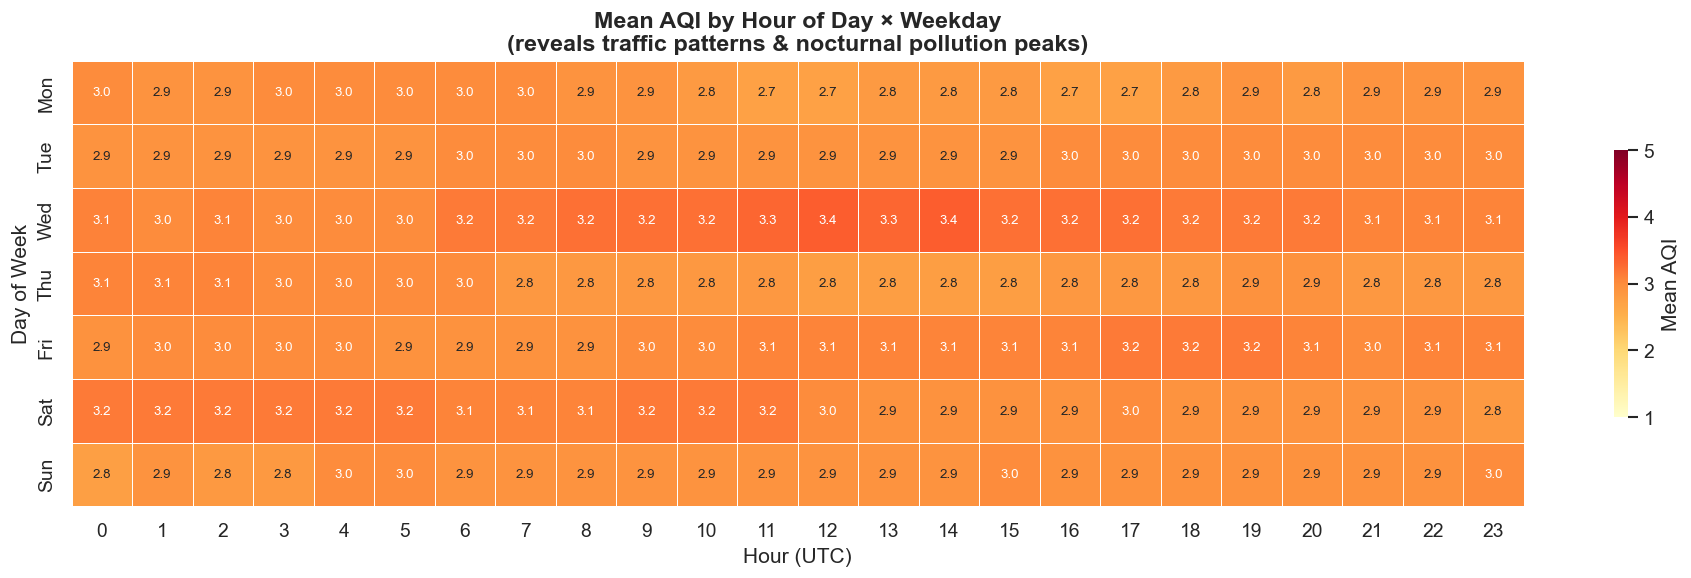

In [23]:
pivot_hw = df.pivot_table(index="weekday", columns="hour", values="aqi", aggfunc="mean")
pivot_hw.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][:len(pivot_hw)]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_hw, cmap="YlOrRd", vmin=1, vmax=5,
    annot=True, fmt=".1f", annot_kws={"size": 8},
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Mean AQI", "shrink": 0.6},
    ax=ax
)
ax.set_title("Mean AQI by Hour of Day × Weekday\n(reveals traffic patterns & nocturnal pollution peaks)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nThe warmest heatmap cells cluster on weekday mornings (04 to 10 UTC), where mean AQI reaches about 3.0 to 3.1. Weekend mornings are slightly cleaner in several hours, but time of day matters more than day of week."))


### Interpretation

The warmest heatmap cells cluster on weekday mornings (04 to 10 UTC), where mean AQI reaches about 3.0 to 3.1. Weekend mornings are slightly cleaner in several hours, but time of day matters more than day of week.


## 12. AQI by Weekday - Violin Plot <a id='12'></a>

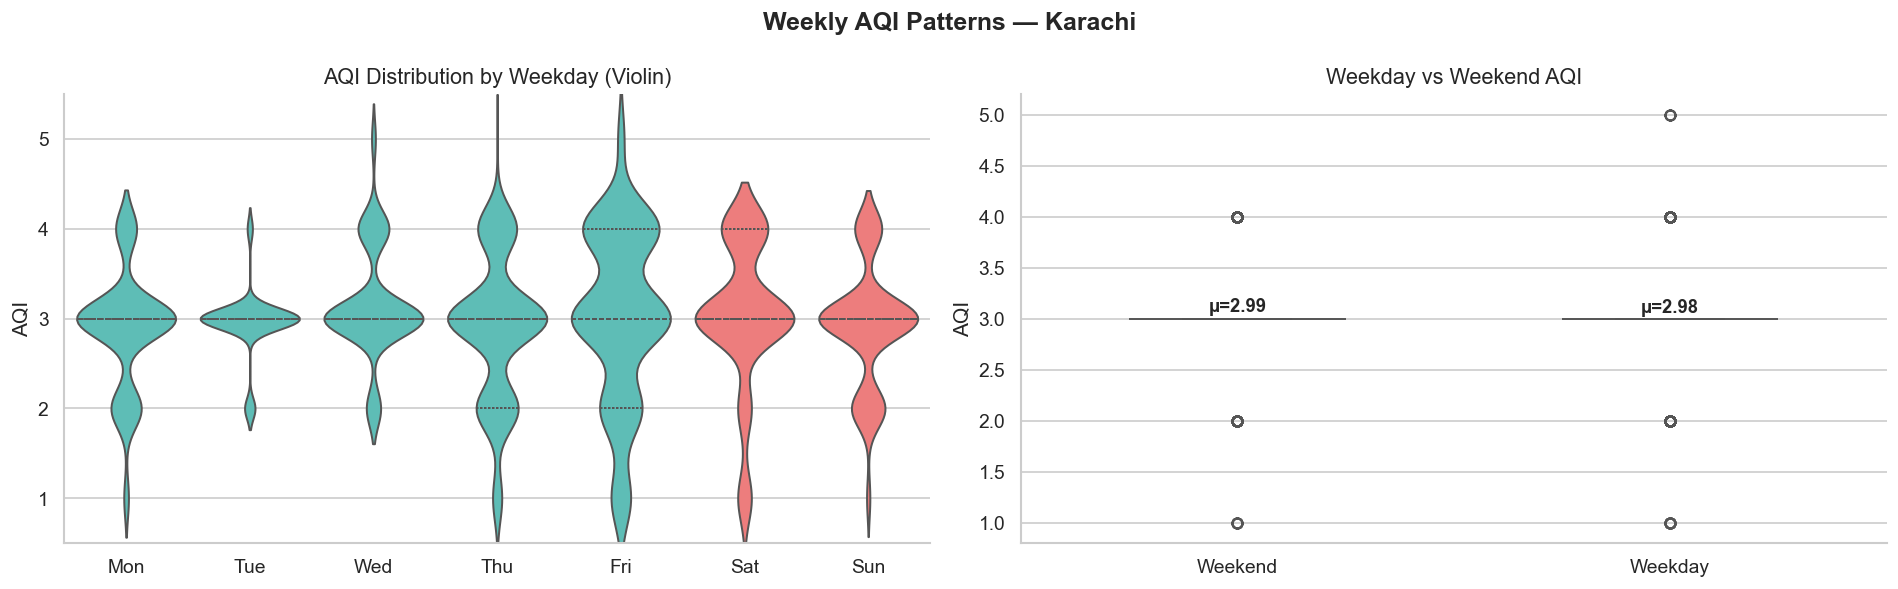

In [24]:
day_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
df["day_name"] = df["weekday"].map(day_map)
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violin
sns.violinplot(
    data=df, x="day_name", y="aqi", order=day_order,
    palette=["#ff6b6b" if d in ["Sat", "Sun"] else "#4ecdc4" for d in day_order],
    inner="quart", linewidth=1.2, ax=axes[0]
)
axes[0].set_title("AQI Distribution by Weekday (Violin)", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("AQI")
axes[0].set_ylim(0.5, 5.5)

# Grouped box — weekday vs weekend
df["is_weekend"] = df["weekday"].isin([5, 6]).map({True: "Weekend", False: "Weekday"})
sns.boxplot(
    data=df, x="is_weekend", y="aqi",
    palette={"Weekday": "#4ecdc4", "Weekend": "#ff6b6b"},
    width=0.5, ax=axes[1]
)
axes[1].set_title("Weekday vs Weekend AQI", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("AQI")

# Add mean annotations
for label, group in df.groupby("is_weekend")["aqi"]:
    x_pos = ["Weekday", "Weekend"].index(label)
    axes[1].text(x_pos, group.mean() + 0.08, f"μ={group.mean():.2f}",
                 ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Weekly AQI Patterns — Karachi", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nMedian AQI sits near 3.0 on every weekday, with Friday showing the widest spread toward Poor and Very Poor categories. Weekday and weekend means are virtually identical (2.98 vs 2.99)."))


### Interpretation

Median AQI sits near 3.0 on every weekday, with Friday showing the widest spread toward Poor and Very Poor categories. Weekday and weekend means are virtually identical (2.98 vs 2.99).


## 13. Monthly / Daily AQI Calendar Heatmap <a id='13'></a>

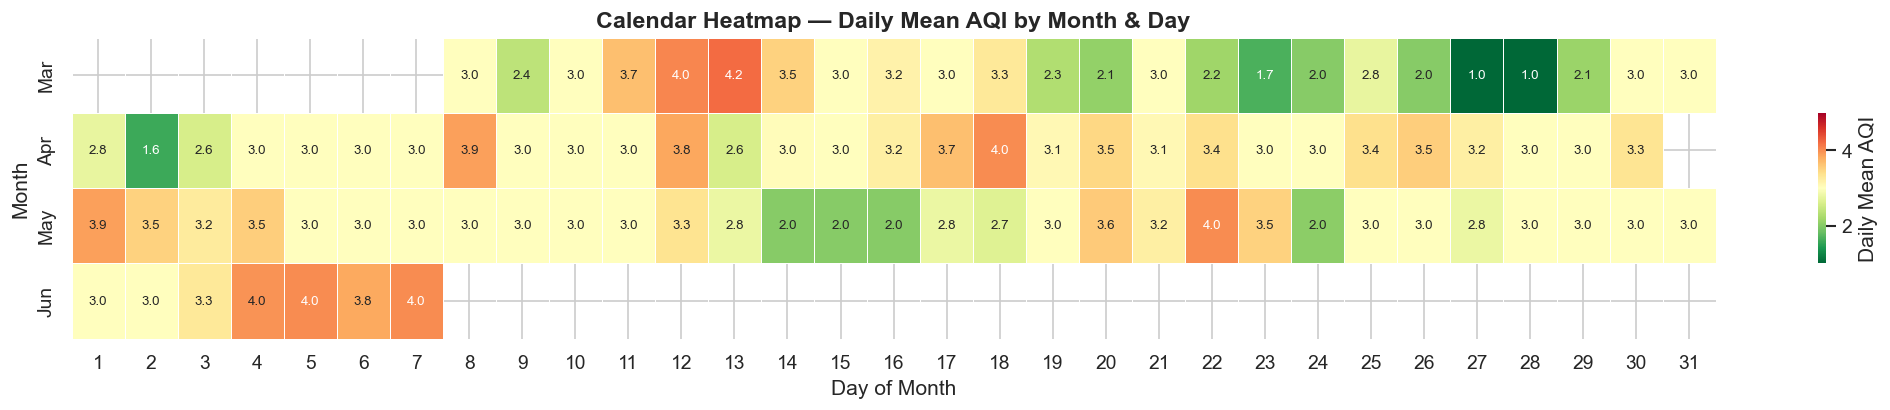

In [26]:
df["day"] = df["datetime"].dt.day
pivot_md = df.pivot_table(index="month", columns="day", values="aqi", aggfunc="mean")
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
pivot_md.index = [month_names[m] for m in pivot_md.index]

fig, ax = plt.subplots(figsize=(18, max(3, len(pivot_md) * 0.9)))
sns.heatmap(
    pivot_md, cmap="RdYlGn_r", vmin=1, vmax=5,
    annot=True, fmt=".1f", annot_kws={"size": 8},
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Daily Mean AQI", "shrink": 0.5},
    ax=ax
)
ax.set_title("Calendar Heatmap — Daily Mean AQI by Month & Day",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nDay to day AQI varies sharply within each month, with occasional clean days near 1.0 in late March and mid May alongside repeated Poor days above 3.5. Early June shows several consecutive days near 4.0."))


### Interpretation

Day to day AQI varies sharply within each month, with occasional clean days near 1.0 in late March and mid May alongside repeated Poor days above 3.5. Early June shows several consecutive days near 4.0.


## 14. Correlation Heatmap <a id='14'></a>

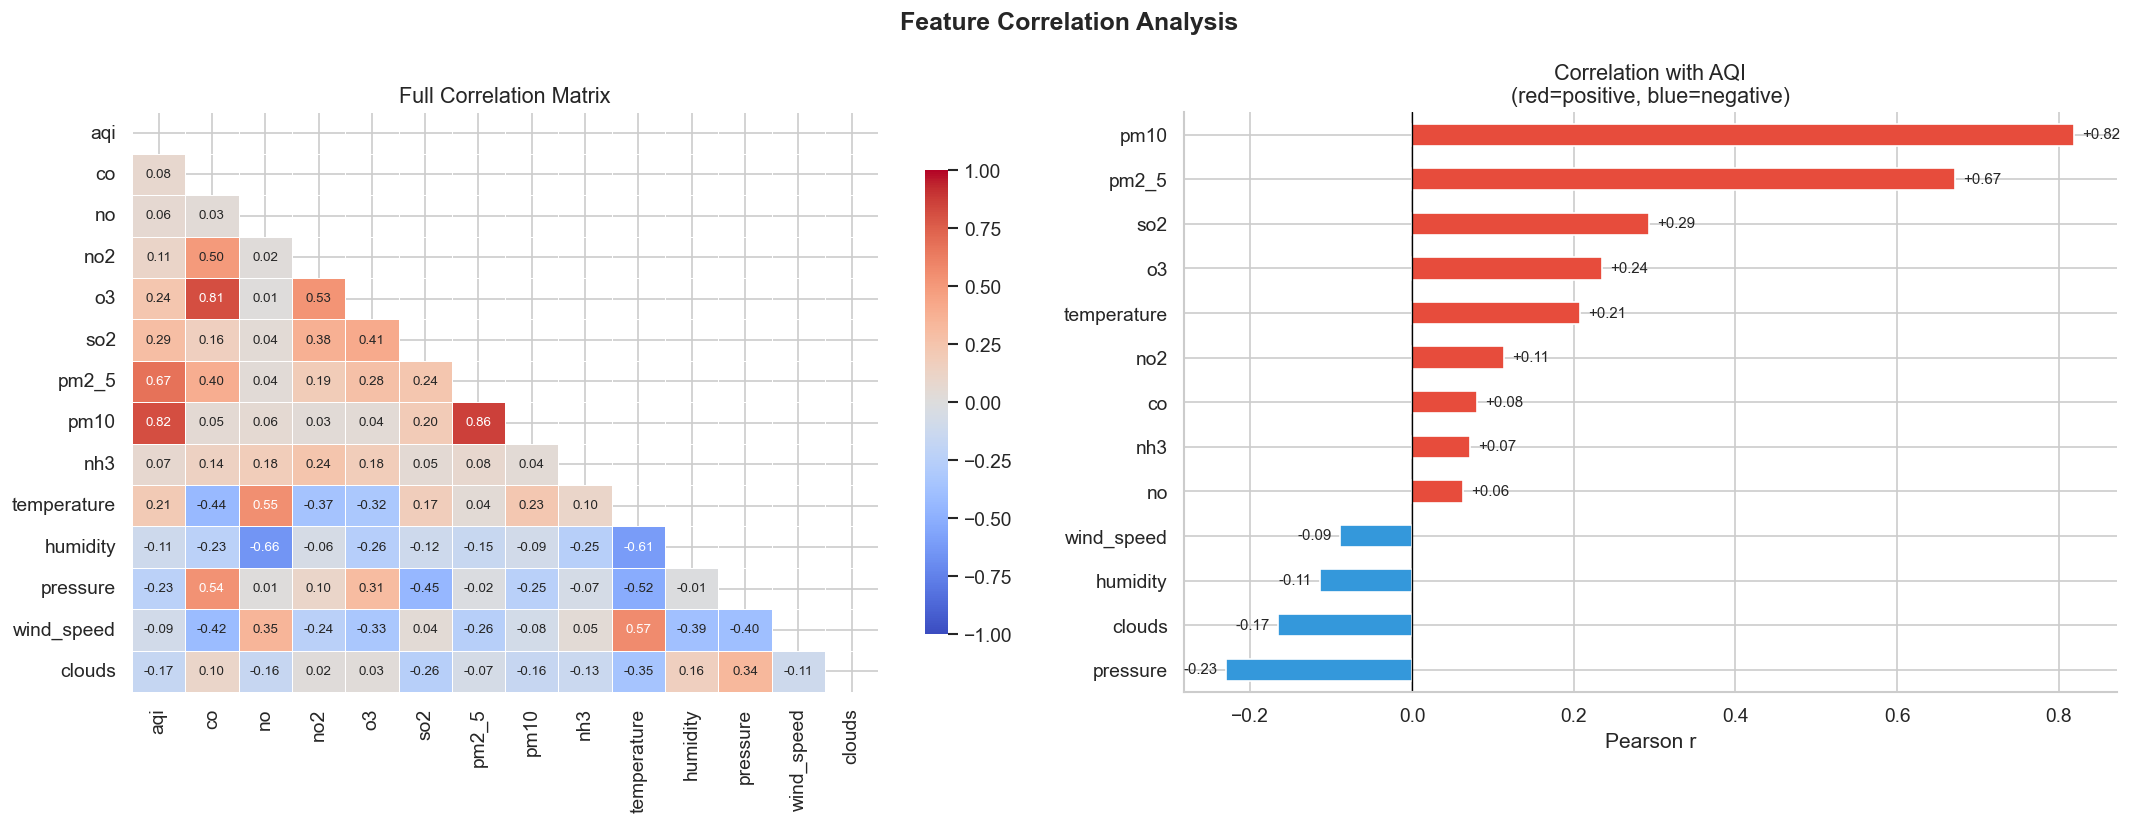

In [27]:
corr_cols = [c for c in numeric_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation matrix (lower triangle)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.4, vmin=-1, vmax=1,
    annot_kws={"size": 8}, ax=axes[0],
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Full Correlation Matrix", fontsize=13)

# Correlation with AQI only — sorted bar
aqi_corr = corr["aqi"].drop("aqi").sort_values()
colors_bar = ["#e74c3c" if v > 0 else "#3498db" for v in aqi_corr]
aqi_corr.plot(kind="barh", ax=axes[1], color=colors_bar, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with AQI\n(red=positive, blue=negative)", fontsize=13)
axes[1].set_xlabel("Pearson r")
for i, v in enumerate(aqi_corr):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.suptitle("Feature Correlation Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nPM10 (r = 0.82) and PM2.5 (r = 0.67) are the strongest correlates of OpenWeather AQI, and PM10 and PM2.5 are highly correlated (r = 0.86). Particulates dominate the AQI signal over meteorology."))


### Interpretation

PM10 (r = 0.82) and PM2.5 (r = 0.67) are the strongest correlates of OpenWeather AQI, and PM10 and PM2.5 are highly correlated (r = 0.86). Particulates dominate the AQI signal over meteorology.


## 15. Pollutants vs AQI: Scatter + Regression <a id='15'></a>

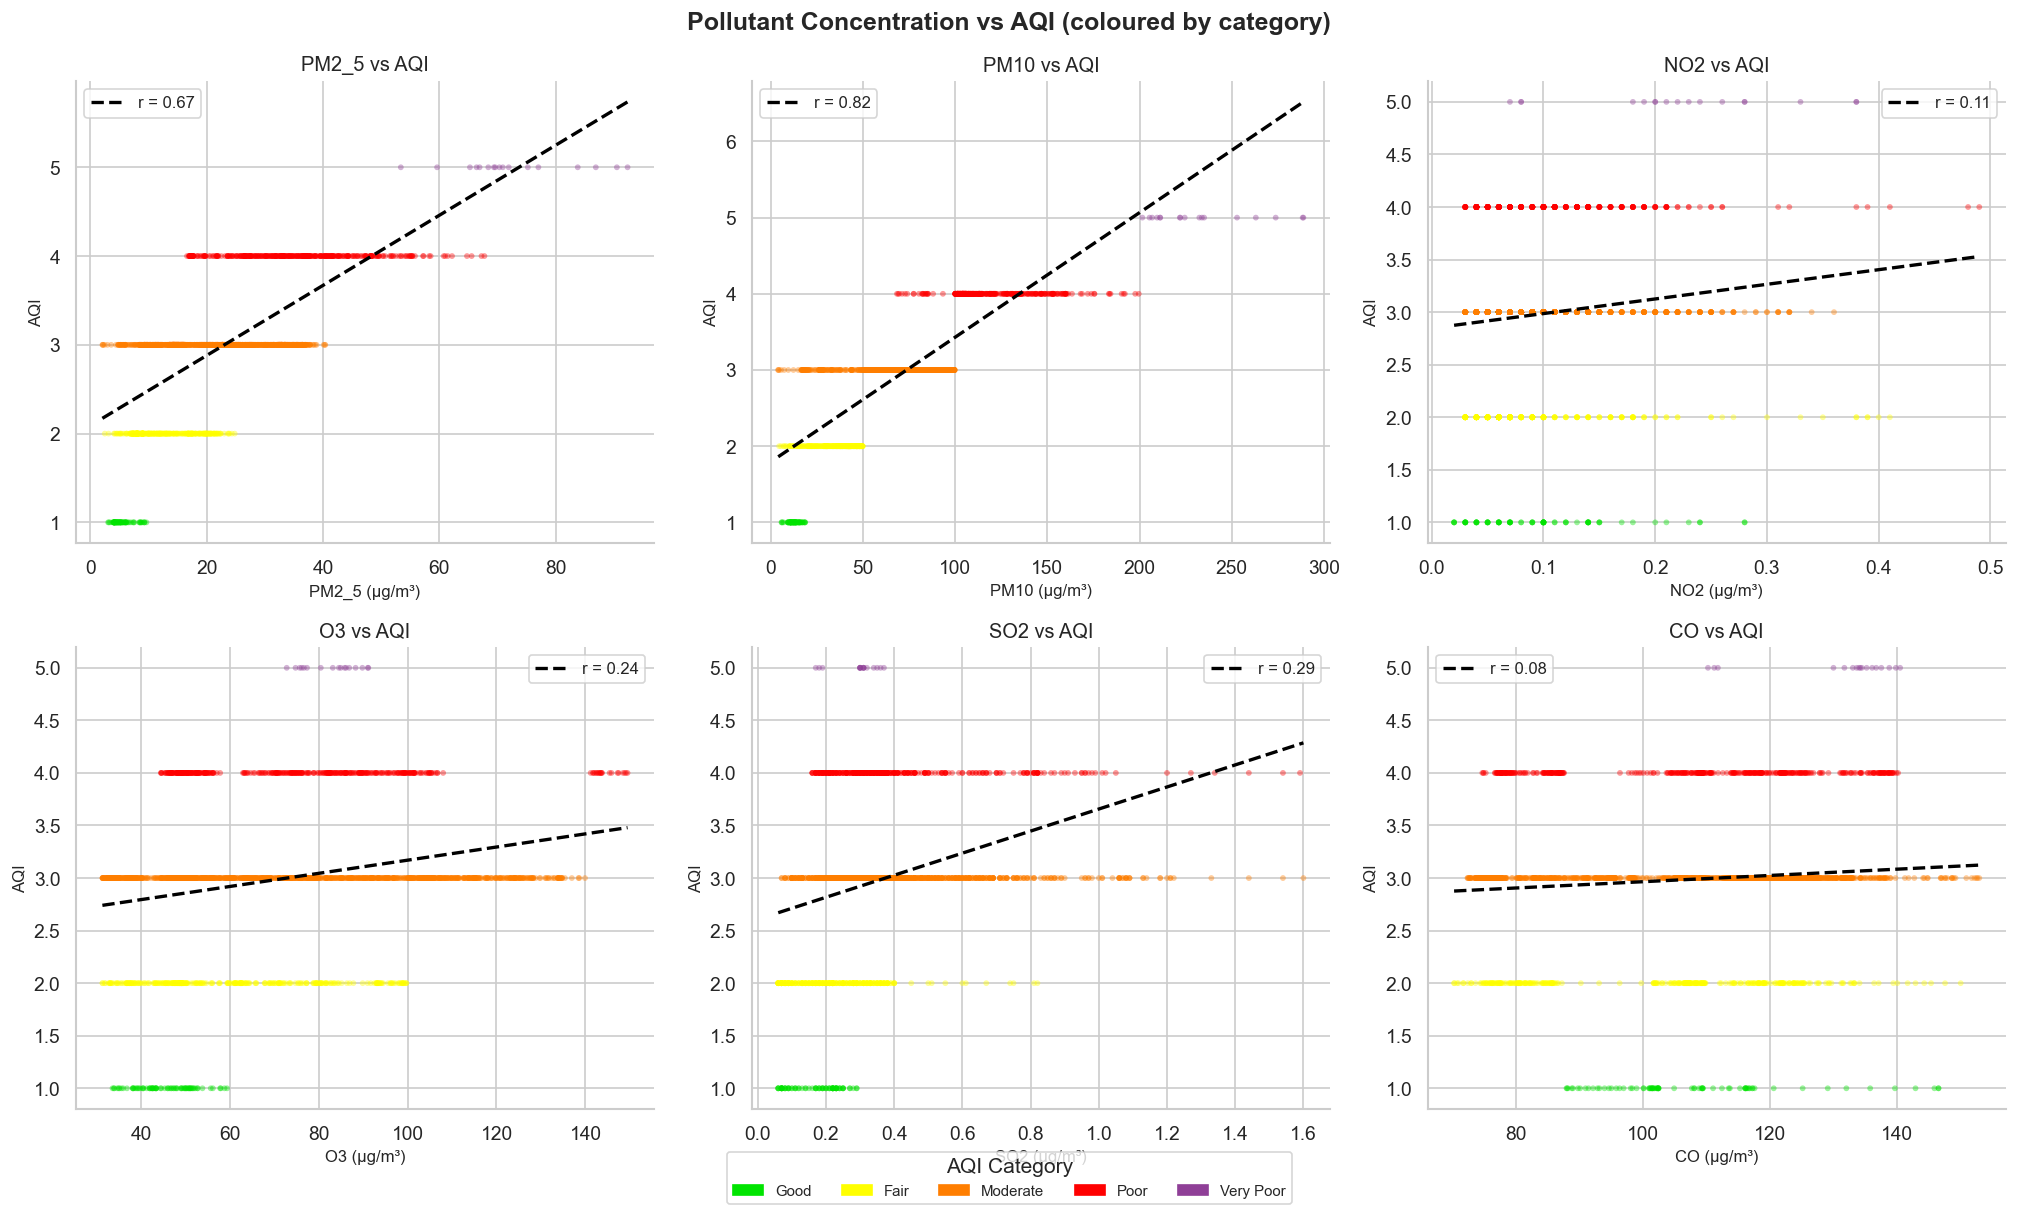

In [28]:
poll_list = [c for c in ["pm2_5", "pm10", "no2", "o3", "so2", "co"] if c in df.columns]
n_cols = 3
n_rows = (len(poll_list) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 5 * n_rows))
axes = axes.flatten()

for i, poll in enumerate(poll_list):
    sub = df[[poll, "aqi"]].dropna()
    r = sub.corr().iloc[0, 1]

    # Colour-code scatter points by AQI category
    point_colors = sub["aqi"].round().clip(1, 5).astype(int).map(AQI_COLORS)
    axes[i].scatter(sub[poll], sub["aqi"],
                    c=point_colors, alpha=0.4, s=12, edgecolors="none")

    # Regression line
    m, b = np.polyfit(sub[poll], sub["aqi"], 1)
    x_range = np.linspace(sub[poll].min(), sub[poll].max(), 100)
    axes[i].plot(x_range, m * x_range + b, color="black", linewidth=2,
                 linestyle="--", label=f"r = {r:.2f}")

    axes[i].set_xlabel(f"{poll.upper()} (μg/m³)", fontsize=10)
    axes[i].set_ylabel("AQI", fontsize=10)
    axes[i].set_title(f"{poll.upper()} vs AQI", fontsize=12)
    axes[i].legend(fontsize=10)

# AQI legend
patches = [mpatches.Patch(color=AQI_COLORS[k], label=AQI_LABELS[k]) for k in AQI_COLORS]
fig.legend(handles=patches, title="AQI Category", loc="lower center",
           ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Pollutant Concentration vs AQI (coloured by category)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nPM10 and PM2.5 scatter plots show the clearest upward trend with AQI category, while NO2, O3, SO2, and especially CO show heavy overlap across categories (r \u2264 0.29). OpenWeather AQI here is particulate driven."))


### Interpretation

PM10 and PM2.5 scatter plots show the clearest upward trend with AQI category, while NO2, O3, SO2, and especially CO show heavy overlap across categories (r ≤ 0.29). OpenWeather AQI here is particulate driven.


## 16. Wind Speed vs AQI <a id='16'></a>

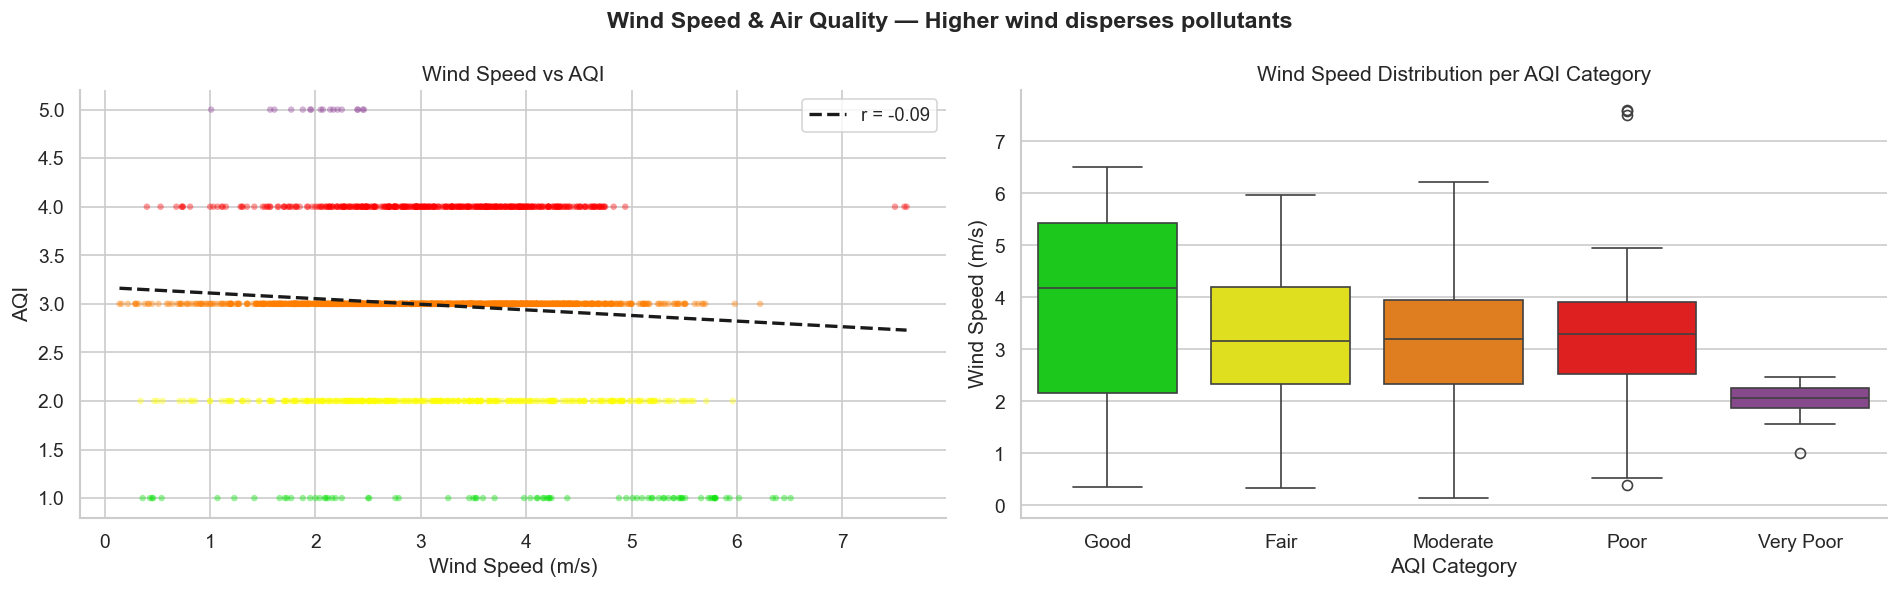

In [30]:
if "wind_speed" in df.columns:
    df["aqi_label"] = df["aqi"].map(AQI_LABELS)
    sub = df[["wind_speed", "aqi", "aqi_label"]].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Scatter coloured by AQI
    point_colors = sub["aqi"].round().clip(1, 5).astype(int).map(AQI_COLORS)
    axes[0].scatter(sub["wind_speed"], sub["aqi"],
                    c=point_colors, alpha=0.4, s=15, edgecolors="none")
    m, b = np.polyfit(sub["wind_speed"], sub["aqi"], 1)
    xr = np.linspace(sub["wind_speed"].min(), sub["wind_speed"].max(), 100)
    r = sub[["wind_speed","aqi"]].corr().iloc[0,1]
    axes[0].plot(xr, m * xr + b, "k--", linewidth=2, label=f"r = {r:.2f}")
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("AQI")
    axes[0].set_title("Wind Speed vs AQI")
    axes[0].legend(fontsize=11)

    # Box plot of wind speed per AQI category
    sns.boxplot(
        data=sub, x="aqi_label",
        y="wind_speed",
        order=[AQI_LABELS[i] for i in range(1,6) if AQI_LABELS[i] in sub["aqi_label"].unique()],
        palette=[AQI_COLORS[i] for i in range(1,6)],
        ax=axes[1]
    )
    axes[1].set_title("Wind Speed Distribution per AQI Category")
    axes[1].set_xlabel("AQI Category")
    axes[1].set_ylabel("Wind Speed (m/s)")

    plt.suptitle("Wind Speed & Air Quality — Higher wind disperses pollutants",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("wind_speed column not available.")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nOverall correlation between wind speed and AQI is weak (r = \u22120.09), but Good air quality coincides with higher wind (median ~4.2 m/s) while Very Poor episodes occur at the lowest wind speeds (median ~2.0 m/s)."))


### Interpretation

Overall correlation between wind speed and AQI is weak (r = −0.09), but Good air quality coincides with higher wind (median ~4.2 m/s) while Very Poor episodes occur at the lowest wind speeds (median ~2.0 m/s).


## 17. Temperature & Humidity vs AQI <a id='17'></a>

In [31]:
met_vars = [(c, lbl) for c, lbl in
            [("temperature", "Temperature (°C)"), ("humidity", "Relative Humidity (%)")]
            if c in df.columns]

if met_vars:
    fig = make_subplots(
        rows=1, cols=len(met_vars),
        subplot_titles=[lbl for _, lbl in met_vars]
    )

    for col_idx, (col, lbl) in enumerate(met_vars, 1):
        sub = df[[col, "aqi"]].dropna()
        r = sub.corr().iloc[0, 1]
        point_colors_hex = sub["aqi"].round().clip(1, 5).astype(int).map(AQI_COLORS)

        fig.add_trace(
            go.Scatter(
                x=sub[col], y=sub["aqi"],
                mode="markers",
                marker=dict(color=point_colors_hex.tolist(), size=5, opacity=0.4),
                name=lbl, showlegend=False
            ),
            row=1, col=col_idx
        )

        # Trend line
        m, b = np.polyfit(sub[col], sub["aqi"], 1)
        xr = np.linspace(sub[col].min(), sub[col].max(), 100)
        fig.add_trace(
            go.Scatter(
                x=xr, y=m * xr + b, mode="lines",
                line=dict(color="black", dash="dash", width=2),
                name=f"r={r:.2f}"
            ),
            row=1, col=col_idx
        )

    fig.update_layout(
        title="Meteorological Variables vs AQI",
        height=450, template=PLOTLY_TEMPLATE
    )
    fig.update_yaxes(title_text="AQI", tickvals=[1,2,3,4,5])
    fig.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nTemperature shows a weak positive association with AQI (r = 0.21). Humidity has an even weaker negative correlation (r = \u22120.11), so meteorological features are secondary to particulate concentrations."))


### Interpretation

Temperature shows a weak positive association with AQI (r = 0.21). Humidity has an even weaker negative correlation (r = −0.11), so meteorological features are secondary to particulate concentrations.


## 18. Pair Plot: Top Correlated Features <a id='18'></a>

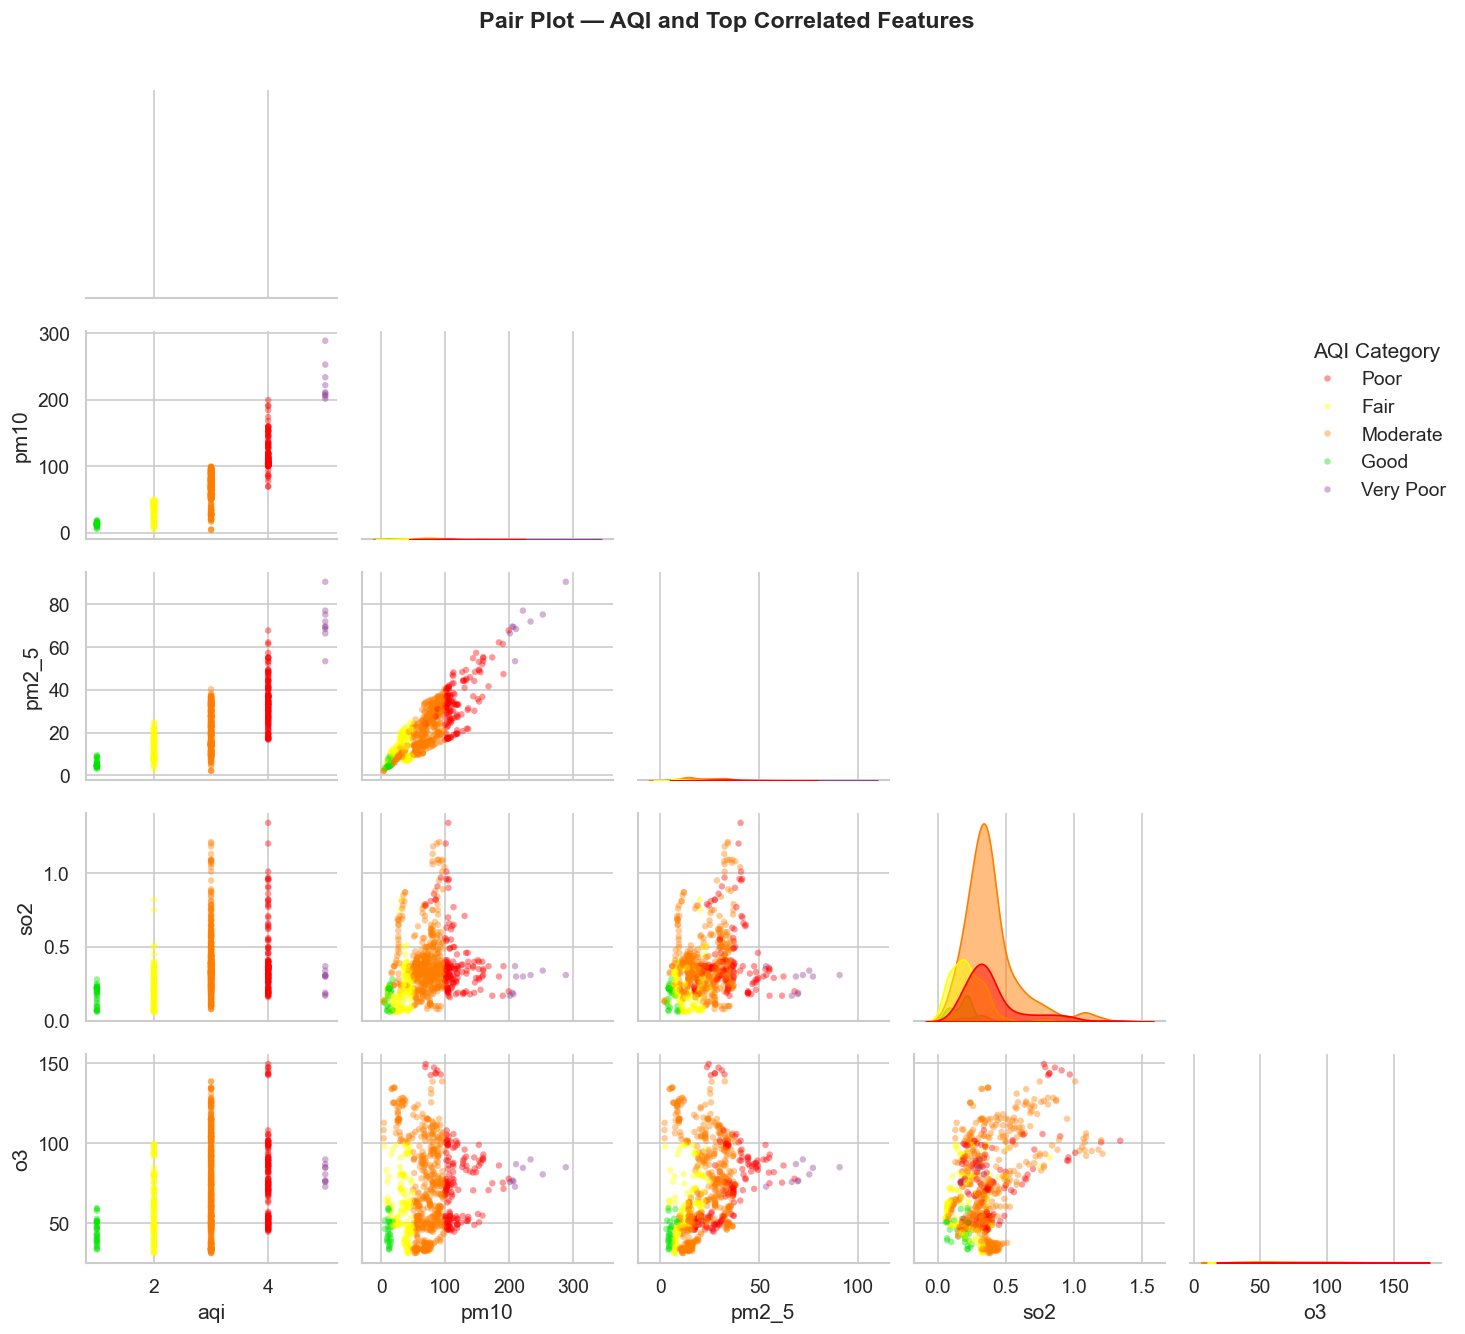

In [32]:
top_features = (df[corr_cols].corr()["aqi"]
                .drop("aqi").abs().sort_values(ascending=False).head(4).index.tolist())
pair_cols = ["aqi"] + top_features
df["aqi_label"] = df["aqi"].map(AQI_LABELS)
pair_df = df[pair_cols + ["aqi_label"]].dropna().sample(min(800, len(df)), random_state=42)

g = sns.PairGrid(
    pair_df, vars=pair_cols,
    hue="aqi_label",
    palette={v: AQI_COLORS[k] for k, v in AQI_LABELS.items()},
    corner=True, height=2.2
)
g.map_lower(sns.scatterplot, alpha=0.4, s=15, edgecolors="none")
g.map_diag(sns.kdeplot, fill=True, alpha=0.5)
g.add_legend(title="AQI Category", bbox_to_anchor=(1, 0.7))
g.figure.suptitle("Pair Plot — AQI and Top Correlated Features",
                  fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nPM10 and PM2.5 separate AQI categories most cleanly in the pair plot. The near linear PM10 vs PM2.5 relationship confirms a shared emission source profile, likely traffic, biomass burning, and spring dust."))


### Interpretation

PM10 and PM2.5 separate AQI categories most cleanly in the pair plot. The near linear PM10 vs PM2.5 relationship confirms a shared emission source profile, likely traffic, biomass burning, and spring dust.


## 19. AQI Autocorrelation: Lag Analysis <a id='19'></a>

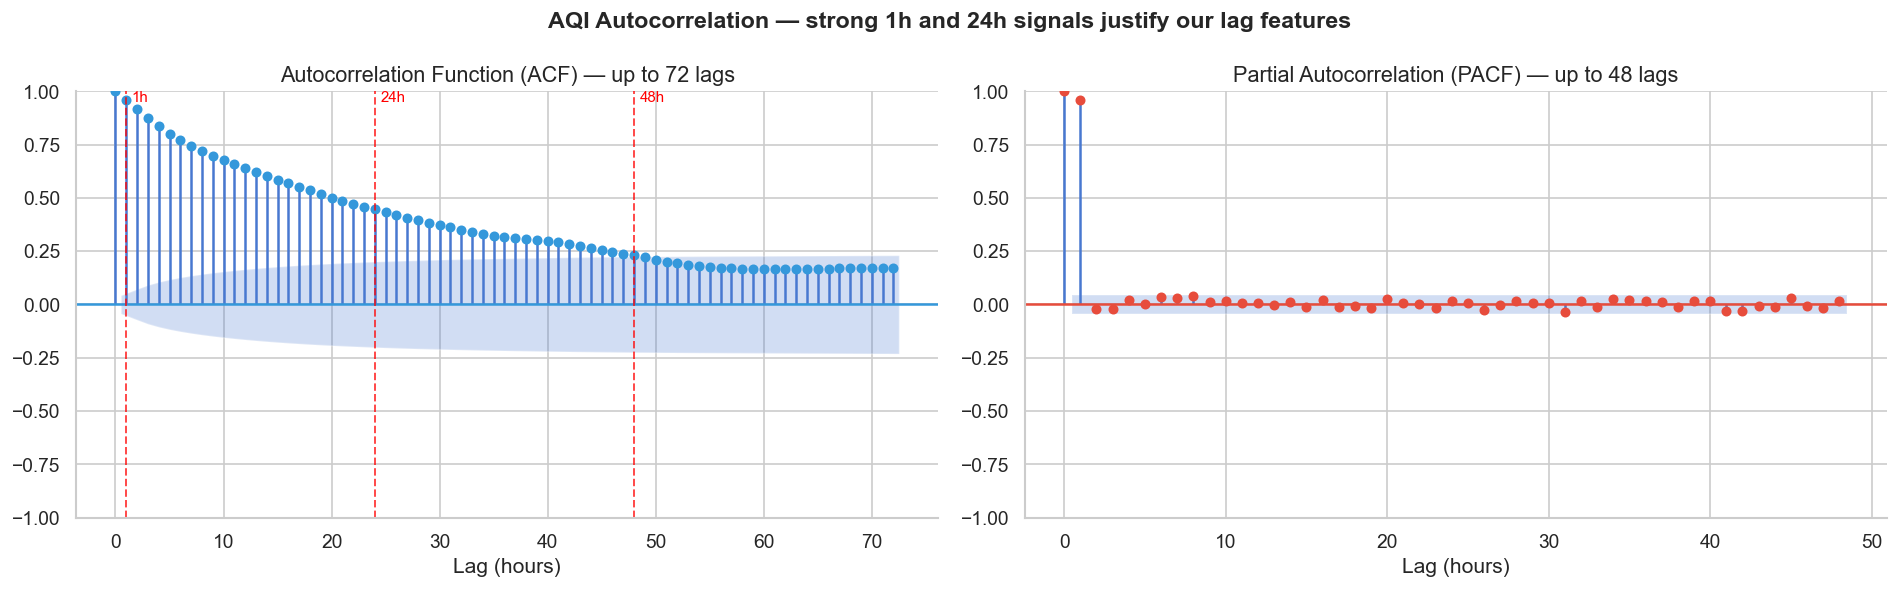


Lag Correlations with current AQI:
         Pearson r with AQI
lag_1h             0.958788
lag_2h             0.917537
lag_6h             0.770521
lag_12h            0.641349
lag_24h            0.451665
lag_48h            0.237009
lag_72h            0.176947


In [33]:
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

aqi_series = df["aqi"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(aqi_series, lags=72, ax=axes[0], alpha=0.05, color="#3498db")
axes[0].set_title("Autocorrelation Function (ACF) — up to 72 lags", fontsize=13)
axes[0].set_xlabel("Lag (hours)")

# Mark key lags
for lag, label in [(1, "1h"), (24, "24h"), (48, "48h")]:
    axes[0].axvline(lag, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
    axes[0].text(lag + 0.5, axes[0].get_ylim()[1] * 0.95, label,
                 color="red", fontsize=9)

plot_pacf(aqi_series, lags=48, ax=axes[1], alpha=0.05, color="#e74c3c", method="ywm")
axes[1].set_title("Partial Autocorrelation (PACF) — up to 48 lags", fontsize=13)
axes[1].set_xlabel("Lag (hours)")

plt.suptitle(
    "AQI Autocorrelation — strong 1h and 24h signals justify our lag features",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Manual lag correlation table
lag_corrs = {f"lag_{h}h": aqi_series.corr(aqi_series.shift(h)) for h in [1, 2, 6, 12, 24, 48, 72]}
lag_df = pd.DataFrame(lag_corrs, index=["Pearson r with AQI"]).T
print("\nLag Correlations with current AQI:")
print(lag_df.to_string())

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nAQI autocorrelation is extremely high at lag 1 hour with visible 24 hour periodic peaks in the ACF. The PACF drops sharply after lag 1, justifying 1 h, 24 h, and 48 h lag features in the feature store."))


### Interpretation

AQI autocorrelation is extremely high at lag 1 hour with visible 24 hour periodic peaks in the ACF. The PACF drops sharply after lag 1, justifying 1 h, 24 h, and 48 h lag features in the feature store.


## 20. Engineered Lag & Rolling Features <a id='20'></a>

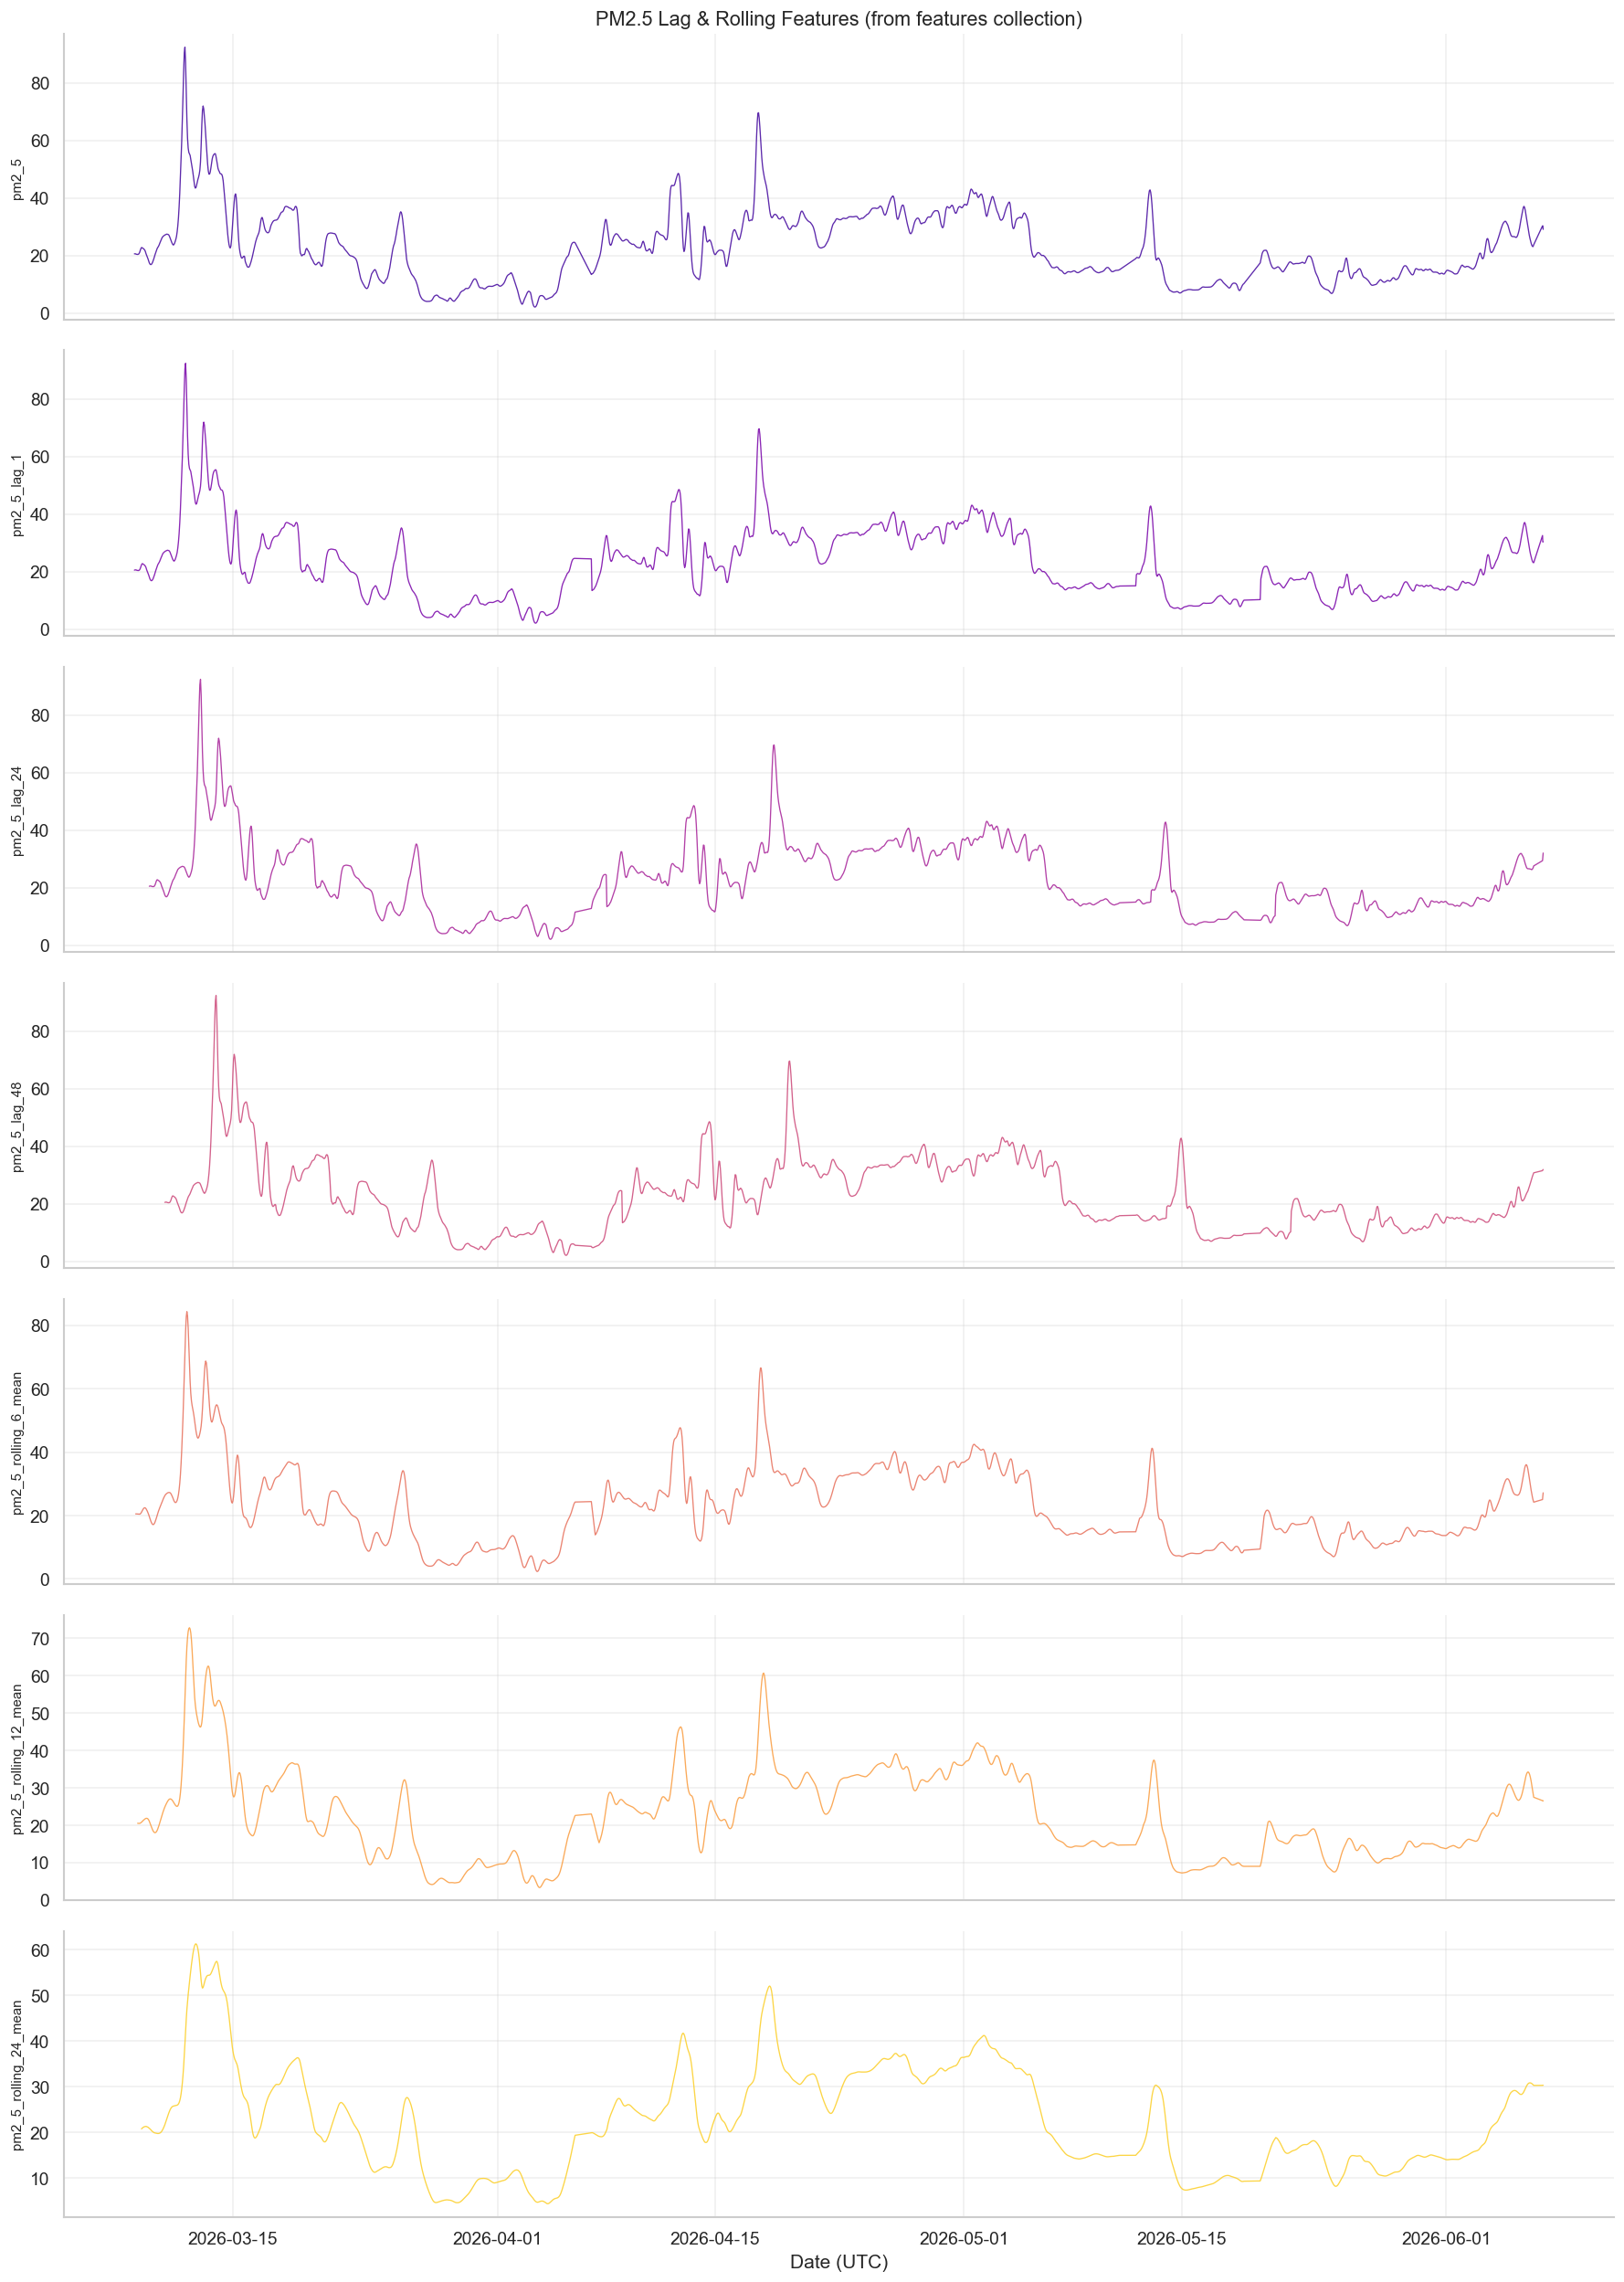

In [35]:
if not feat_df.empty:
    # Show PM2.5 lag/rolling features as representative example
    lag_features = [c for c in ["pm2_5", "pm2_5_lag_1", "pm2_5_lag_24", "pm2_5_lag_48",
                                 "pm2_5_rolling_6_mean", "pm2_5_rolling_12_mean",
                                 "pm2_5_rolling_24_mean"] if c in feat_df.columns]
    if lag_features:
        fig, axes = plt.subplots(len(lag_features), 1, figsize=(15, 3 * len(lag_features)),
                                 sharex=True)
        if len(lag_features) == 1:
            axes = [axes]
        colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(lag_features)))
        for ax, feat, color in zip(axes, lag_features, colors):
            ax.plot(feat_df["datetime"], feat_df[feat], color=color, linewidth=0.8, alpha=0.85)
            ax.set_ylabel(feat, fontsize=9)
            ax.grid(alpha=0.3)
        axes[-1].set_xlabel("Date (UTC)")
        axes[0].set_title("PM2.5 Lag & Rolling Features (from features collection)", fontsize=13)
        plt.tight_layout()
        plt.show()
    else:
        print("PM2.5 lag features not found in feat_df. Run backfill.py --rebuild-features")

    overlay_features = [c for c in ["pm2_5", "pm2_5_lag_1", "pm2_5_lag_24", "pm2_5_lag_48",
                                    "pm2_5_rolling_24_mean"] if c in feat_df.columns]
    if overlay_features:
        fig = go.Figure()
        styles = [
            dict(color="rgba(100,149,237,0.9)", width=1.5, dash="solid"),
            dict(color="rgba(255,127,14,0.8)",  width=1,   dash="dot"),
            dict(color="rgba(44,160,44,0.8)",   width=1,   dash="dash"),
            dict(color="rgba(214,39,40,0.8)",   width=1,   dash="dashdot"),
            dict(color="rgba(148,103,189,1.0)", width=2.5, dash="solid"),
        ]
        for feat, style in zip(overlay_features, styles):
            fig.add_trace(go.Scatter(
                x=feat_df["datetime"], y=feat_df[feat],
                mode="lines", name=feat, line=style
            ))

        fig.update_layout(
            title="Current PM2.5 vs Lag & Rolling Features over Time",
            xaxis_title="Date", yaxis_title="PM2.5 (µg/m³)",
            height=480, template=PLOTLY_TEMPLATE,
            legend=dict(orientation="h", yanchor="bottom", y=1.02)
        )
        fig.show()
else:
    print("Feature DataFrame is empty. Run feature_engineering.py first.")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nRaw PM2.5 is noisy at hourly resolution, while rolling means progressively smooth the series and highlight multi day pollution episodes. Lagged series track the same March and April spikes."))


### Interpretation

Raw PM2.5 is noisy at hourly resolution, while rolling means progressively smooth the series and highlight multi day pollution episodes. Lagged series track the same March and April spikes.


## 21. AQI Change Rate Distribution <a id='21'></a>

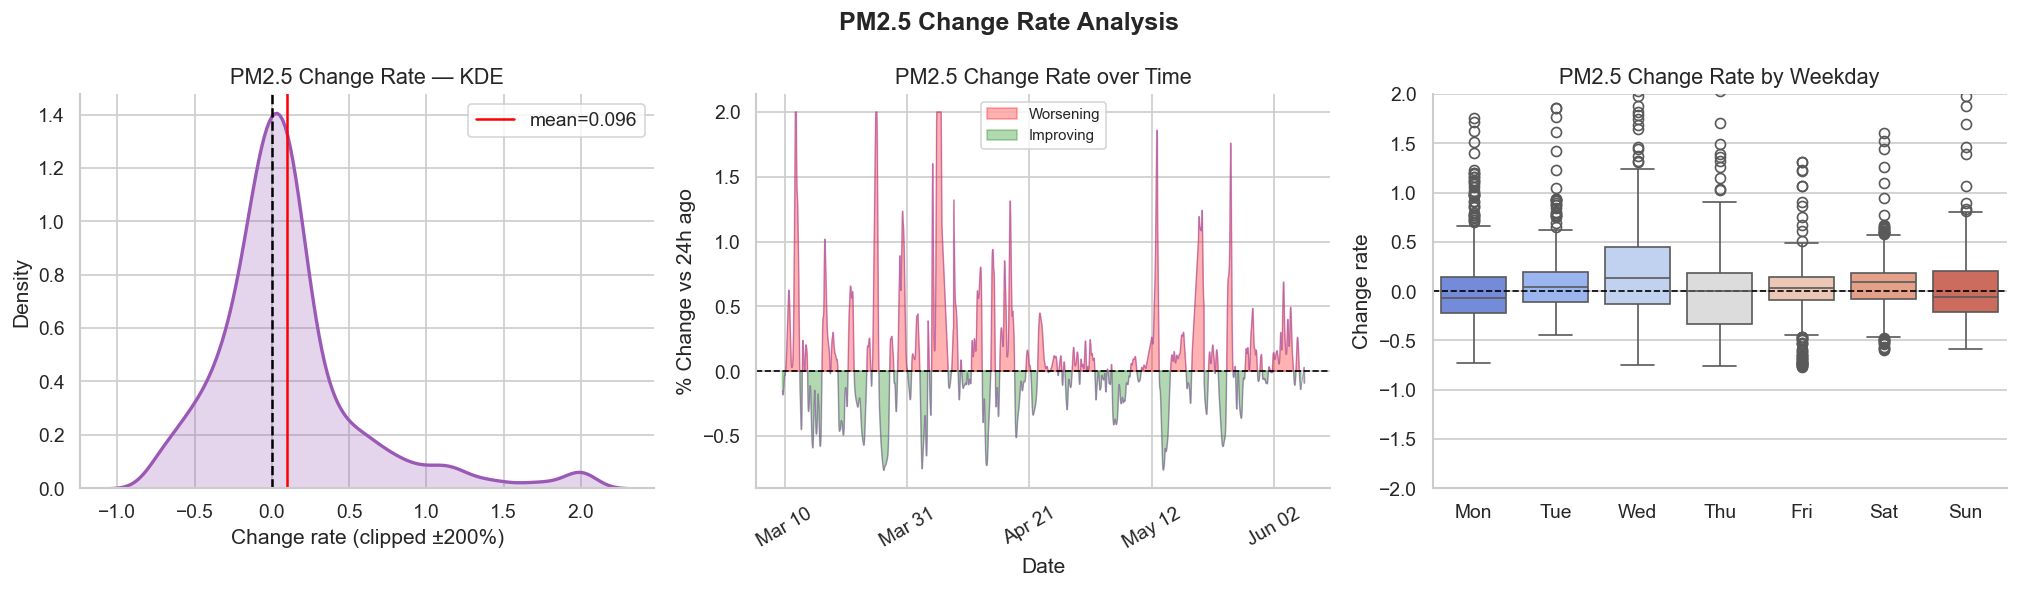

In [37]:
if not feat_df.empty and "pm2_5_change_rate" in feat_df.columns:
    cr_df = feat_df[["datetime", "pm2_5_change_rate"]].dropna().copy()
    cr = cr_df["pm2_5_change_rate"]
    cr_clipped = cr.clip(-2, 2)  # clip outliers for display

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # KDE
    sns.kdeplot(cr_clipped, ax=axes[0], fill=True, color="#9b59b6", linewidth=2)
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5)
    axes[0].axvline(cr.mean(), color="red", linestyle="-", linewidth=1.5,
                    label=f"mean={cr.mean():.3f}")
    axes[0].set_title("PM2.5 Change Rate — KDE", fontsize=13)
    axes[0].set_xlabel("Change rate (clipped ±200%)")
    axes[0].legend()

    # Over time
    axes[1].plot(cr_df["datetime"], cr_clipped, linewidth=0.6, color="#9b59b6", alpha=0.7)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].fill_between(cr_df["datetime"], 0, cr_clipped,
                          where=cr_clipped > 0, alpha=0.3, color="red", label="Worsening")
    axes[1].fill_between(cr_df["datetime"], 0, cr_clipped,
                          where=cr_clipped < 0, alpha=0.3, color="green", label="Improving")
    axes[1].set_title("PM2.5 Change Rate over Time", fontsize=13)
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("% Change vs 24h ago")
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
    plt.setp(axes[1].get_xticklabels(), rotation=30)

    # Box per weekday
    cr_df["day_name"] = cr_df["datetime"].dt.weekday.map(day_map)
    sns.boxplot(
        data=cr_df, x="day_name", y="pm2_5_change_rate",
        order=day_order, palette="coolwarm", ax=axes[2]
    )
    axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[2].set_ylim(-2, 2)
    axes[2].set_title("PM2.5 Change Rate by Weekday", fontsize=13)
    axes[2].set_xlabel("")
    axes[2].set_ylabel("Change rate")

    plt.suptitle("PM2.5 Change Rate Analysis", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("pm2_5_change_rate not available.")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nPM2.5 change rate is slightly right skewed with mean +0.096, meaning pollution more often worsens than improves over 24 hours. Large positive spikes above 150% occur intermittently in late March and mid May."))


### Interpretation

PM2.5 change rate is slightly right skewed with mean +0.096, meaning pollution more often worsens than improves over 24 hours. Large positive spikes above 150% occur intermittently in late March and mid May.


## 22. Target Variable Distributions <a id='22'></a>

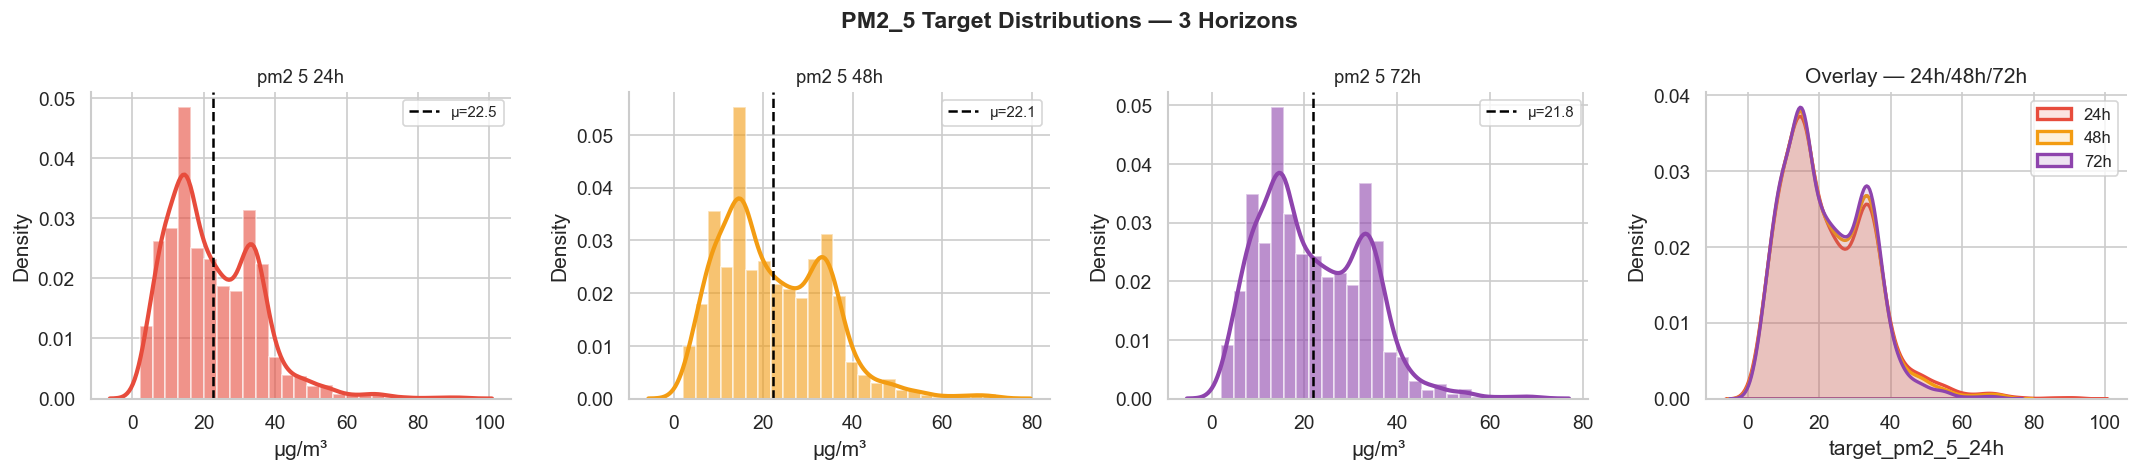

       target_pm2_5_24h  target_pm2_5_48h  target_pm2_5_72h
count           1971.00           1971.00           1971.00
mean              22.47             22.07             21.76
std               12.66             11.82             11.24
min                2.06              2.06              2.06
25%               13.39             13.39             13.39
50%               19.88             19.88             19.88
75%               32.26             31.66             31.46
max               92.39             71.95             69.63



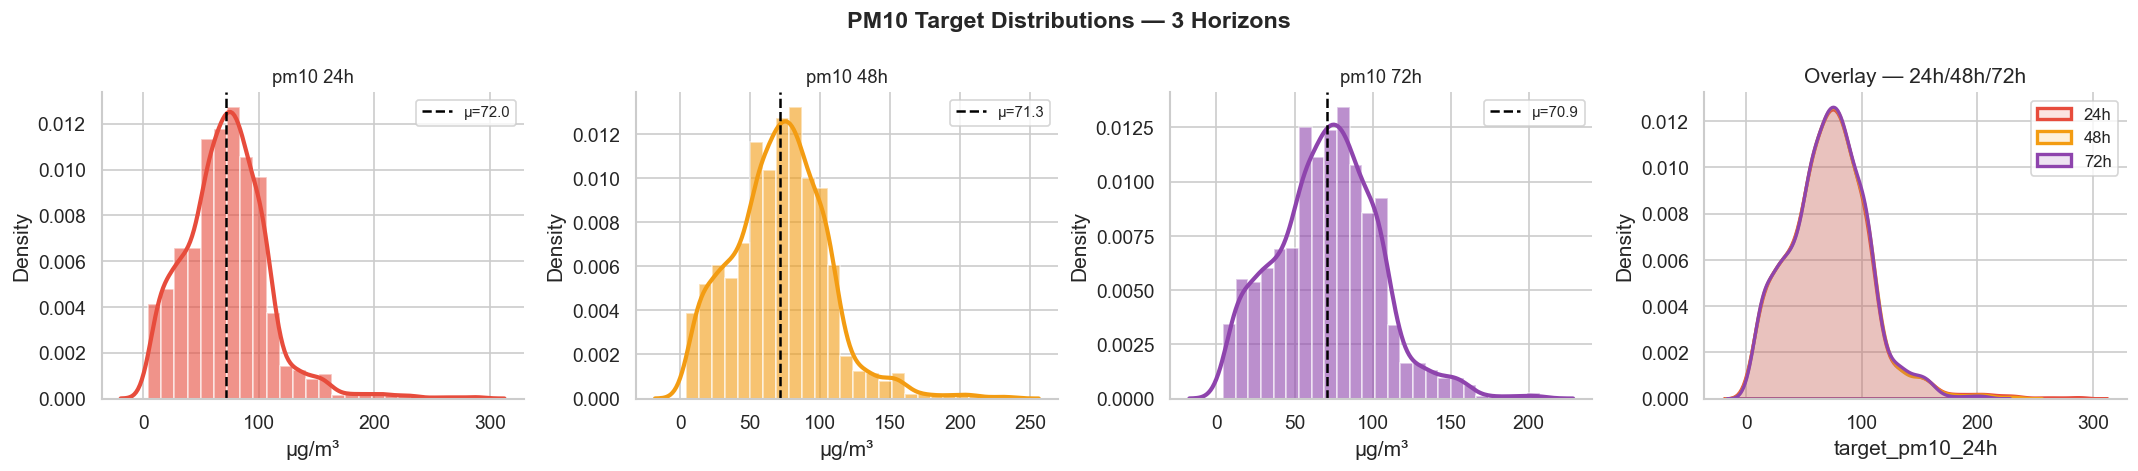

       target_pm10_24h  target_pm10_48h  target_pm10_72h
count          1971.00          1971.00          1971.00
mean             72.00            71.27            70.91
std              35.98            33.72            32.69
min               4.13             4.13             4.13
25%              49.42            49.42            49.42
50%              71.23            71.23            71.23
75%              91.98            91.98            91.98
max             288.85           233.81           206.87



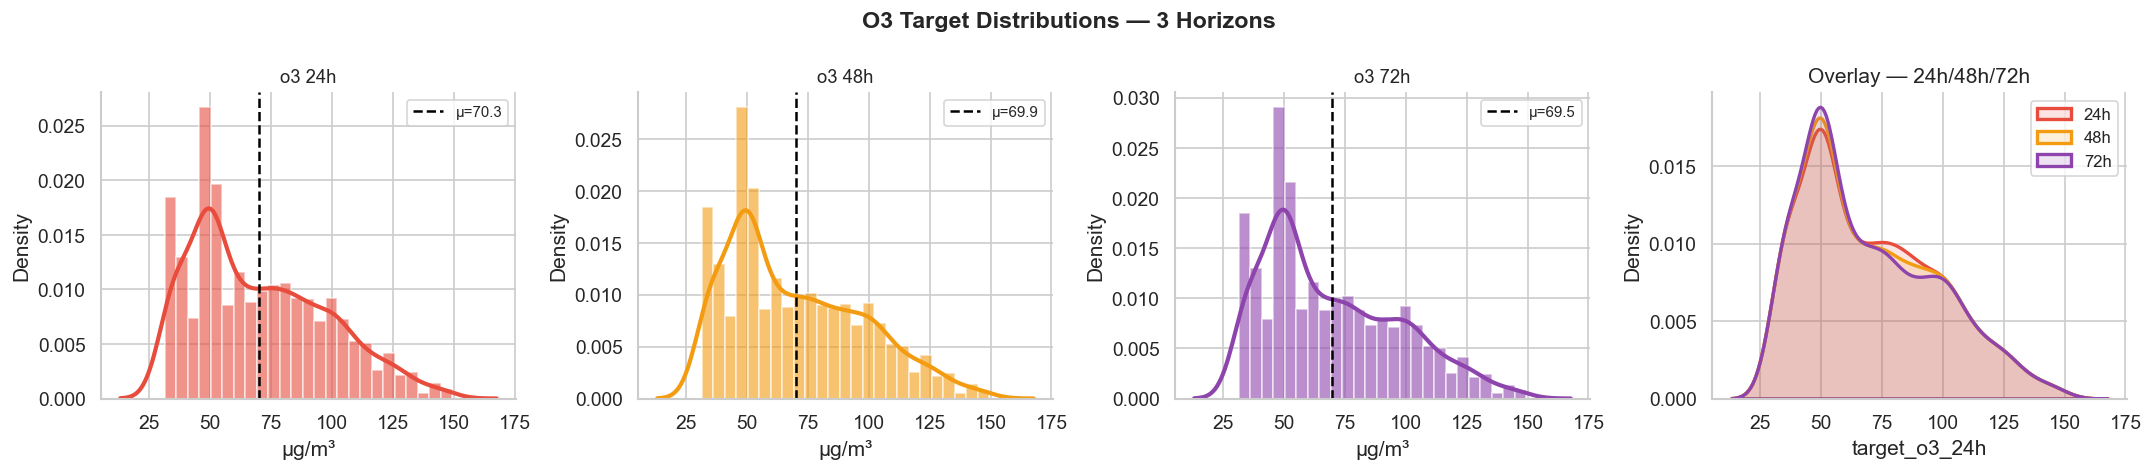

       target_o3_24h  target_o3_48h  target_o3_72h
count        1971.00        1971.00        1971.00
mean           70.31          69.90          69.47
std            27.65          27.73          27.74
min            31.33          31.33          31.33
25%            48.40          48.26          48.20
50%            64.63          63.65          62.78
75%            90.29          90.29          90.17
max           149.49         149.49         149.49



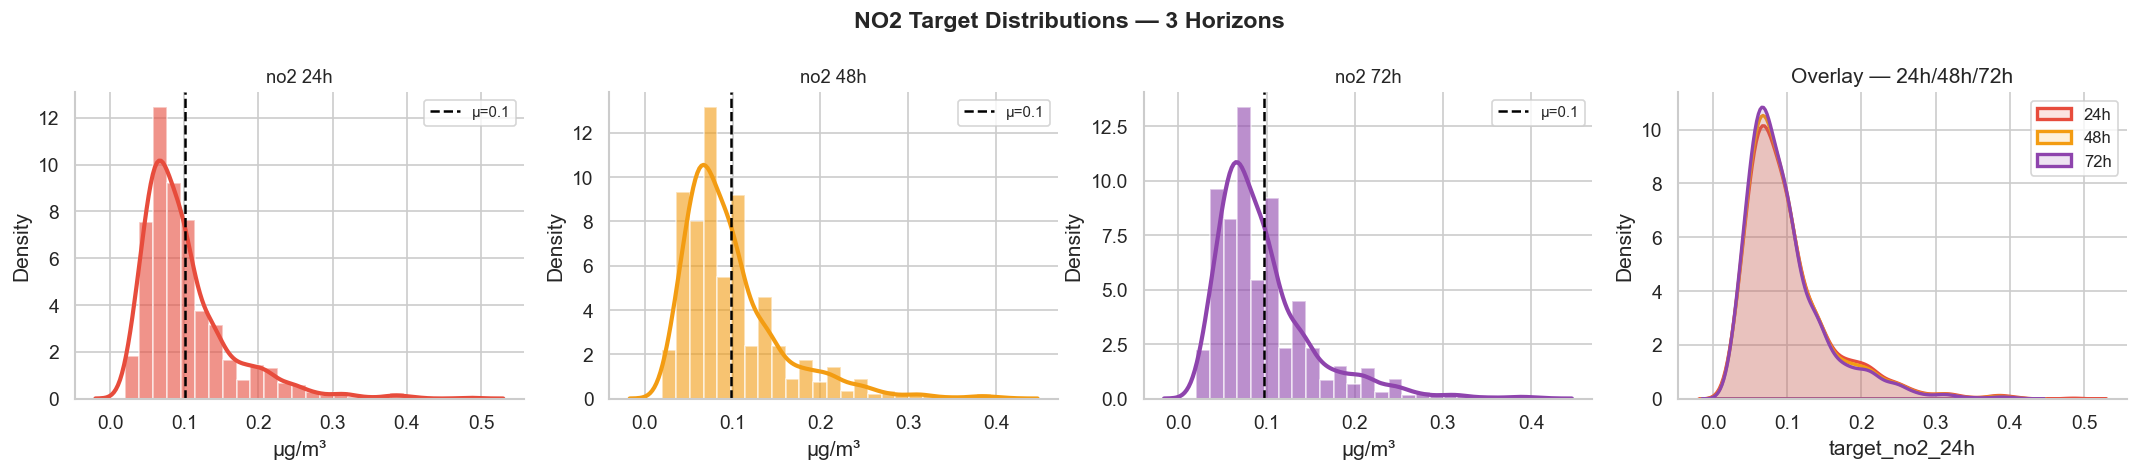

       target_no2_24h  target_no2_48h  target_no2_72h
count         1971.00         1971.00         1971.00
mean             0.10            0.10            0.10
std              0.06            0.06            0.06
min              0.02            0.02            0.02
25%              0.06            0.06            0.06
50%              0.09            0.08            0.08
75%              0.12            0.12            0.11
max              0.49            0.41            0.41



In [38]:
# Target variable distributions — pollutant targets (4 pollutants × 3 horizons)
# Uses train_df: feature rows WITH all 12 target columns from the features collection.

if not train_df.empty:
    for pollutant in ["pm2_5", "pm10", "o3", "no2"]:
        targets = [f"target_{pollutant}_{h}h" for h in [24, 48, 72]
                   if f"target_{pollutant}_{h}h" in train_df.columns]
        if not targets:
            continue
        colors_t = ["#e74c3c", "#f39c12", "#8e44ad"]
        fig, axes = plt.subplots(1, len(targets) + 1, figsize=(18, 4))
        for i, (tgt, col) in enumerate(zip(targets, colors_t)):
            data = train_df[tgt].dropna()
            axes[i].hist(data, bins=25, color=col, alpha=0.6, edgecolor="white", density=True)
            sns.kdeplot(data, ax=axes[i], color=col, linewidth=2.5)
            axes[i].axvline(data.mean(), color="black", linestyle="--",
                            linewidth=1.5, label=f"μ={data.mean():.1f}")
            axes[i].set_title(f"{tgt.replace('target_','').replace('_',' ')}", fontsize=11)
            axes[i].set_xlabel("μg/m³"); axes[i].set_ylabel("Density"); axes[i].legend(fontsize=9)
        for tgt, col in zip(targets, colors_t):
            data = train_df[tgt].dropna()
            sns.kdeplot(data, ax=axes[-1], color=col, linewidth=2, label=tgt.split("_")[-1], fill=True, alpha=0.15)
        axes[-1].set_title("Overlay — 24h/48h/72h")
        axes[-1].legend(fontsize=10)
        plt.suptitle(f"{pollutant.upper()} Target Distributions — 3 Horizons", fontsize=14, fontweight="bold")
        plt.tight_layout(); plt.show()
        print(train_df[targets].describe().round(2).to_string())
        print()
else:
    print("No training rows. Run:  python src/backfill.py --rebuild-features")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nTarget PM2.5 distributions are bimodal (peaks near 15 and 35 \u00b5g/m\u00b3) with stable means across 24 h, 48 h, and 72 h horizons (22.5 to 21.8). PM10 targets are right skewed (mean ~72 \u00b5g/m\u00b3); each pollutant needs its own model."))


### Interpretation

Target PM2.5 distributions are bimodal (peaks near 15 and 35 µg/m³) with stable means across 24 h, 48 h, and 72 h horizons (22.5 to 21.8). PM10 targets are right skewed (mean ~72 µg/m³); each pollutant needs its own model.


## 23. Feature Importance Preview <a id='23'></a>

it fits a lightweight Random Forest on the 24h target to rank features
before formal training: a useful sanity check.

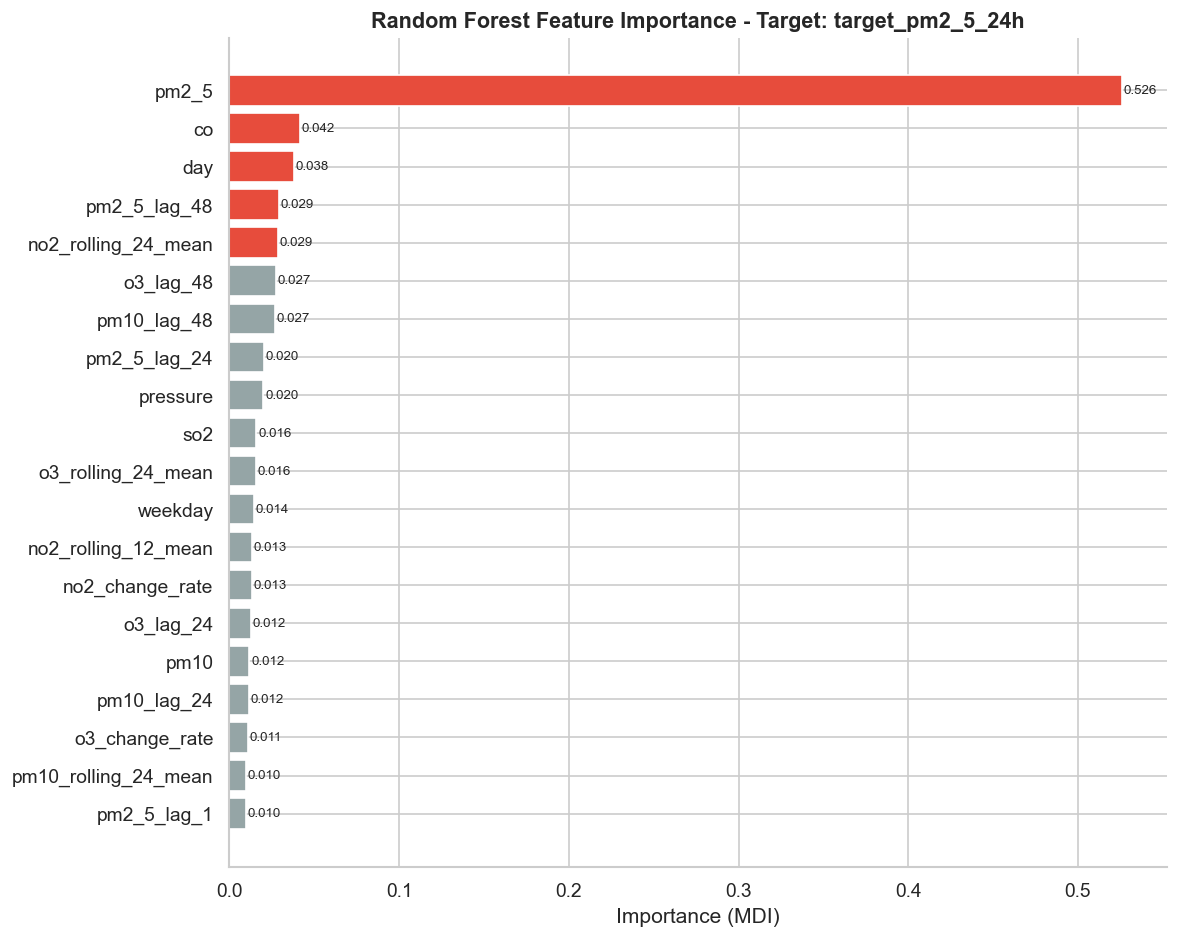


Top 5 most important features:
            feature  importance
no2_rolling_24_mean    0.028593
       pm2_5_lag_48    0.029176
                day    0.038036
                 co    0.041610
              pm2_5    0.526012


In [40]:
TARGET_FOR_IMPORTANCE = "target_pm2_5_24h"

if not train_df.empty and TARGET_FOR_IMPORTANCE in train_df.columns:
    from sklearn.ensemble import RandomForestRegressor
    from src.config import FEATURE_COLUMNS

    feature_cols = [c for c in FEATURE_COLUMNS if c in train_df.columns]
    sub = train_df[feature_cols + [TARGET_FOR_IMPORTANCE]].dropna()

    X = sub[feature_cols].values
    y = sub[TARGET_FOR_IMPORTANCE].values

    rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=True)

    top20 = importance_df.tail(20)
    fig, ax = plt.subplots(figsize=(10, max(5, len(top20) * 0.4)))
    bar_colors = ["#e74c3c" if i >= len(top20) - 5 else "#95a5a6"
                  for i in range(len(top20))]
    bars = ax.barh(top20["feature"], top20["importance"],
                   color=bar_colors, edgecolor="white")
    ax.set_title(f"Random Forest Feature Importance - Target: {TARGET_FOR_IMPORTANCE}",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance (MDI)")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{w:.3f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nTop 5 most important features:")
    print(importance_df.tail(5)[["feature", "importance"]].to_string(index=False))
else:
    print(f"Column '{TARGET_FOR_IMPORTANCE}' not found. Run backfill --rebuild-features first.")

from IPython.display import Markdown, display
display(Markdown("### Interpretation\n\nA quick Random Forest on target_pm2_5_24h shows current PM2.5 concentration dominates importance (0.526). Secondary signals include CO, calendar day, and 48 h PM2.5 lag."))


### Interpretation

A quick Random Forest on target_pm2_5_24h shows current PM2.5 concentration dominates importance (0.526). Secondary signals include CO, calendar day, and 48 h PM2.5 lag.


## 24. Key Insights & Modelling Implications <a id='24'></a>

### Pollutant First AQI Approach

This project uses a **pollutant first AQI forecasting** system:

1. **Forecast:** ML models predict PM2.5, PM10, O3, and NO2 at +24h, +48h, and +72h horizons.
2. **Convert:** Each concentration maps to an EPA AQI sub index via breakpoint interpolation.
3. **Final AQI:** The maximum sub index (dominant pollutant) becomes the reported AQI.


### Key Findings: Karachi Air Quality (Mar to Jun 2026)

**Data quality:** ~2,090 hourly records with zero missing values across pollutants and weather fields. No imputation required.

**Dominant pollution profile:** PM2.5 drives computed AQI on ~73% of hours, PM10 on ~15%, with minor O3 and NO2 contributions. OpenWeather category AQI is overwhelmingly particulate driven (PM10 r = 0.82, PM2.5 r = 0.67).

**Severity:** Fair and Moderate categories each account for ~35% of readings. Good (AQI 1) is rare. Daily PM2.5 and PM10 frequently exceed WHO 24h guidelines during March and April, when computed EPA AQI peaked near 177.

**Temporal patterns:**

| Pattern | Observation | Likely cause |
|---|---|---|
| Hour of day | Peaks 03 to 10 UTC | Nocturnal boundary layer, low wind, accumulated emissions |
| Hour of day | Improvement 11 to 14 UTC | Daytime mixing and sea breeze |
| Weekday | Median AQI ~3 every day | Weak weekly seasonality (weekday mean 2.98, weekend mean 2.99) |
| Monthly | March highest daily means (~3.3) | Spring dust and pre monsoon dryness |
| Calendar | High day to day variance | Episodic spikes, not smooth seasonal curves |

**Meteorology:** Wind speed shows weak linear correlation (r = −0.09) but Very Poor episodes cluster at the lowest wind speeds (median ~2 m/s). Temperature (r = +0.21) and humidity (r = −0.11) are secondary modifiers.

**Autocorrelation and features:** AQI ACF is near 1.0 at lag 1h with clear 24h and 48h cycles. PM2.5 lag, rolling mean, and change rate features capture this persistence. Target distributions stay stable across 24h/48h/72h horizons.

**Feature importance preview:** Current PM2.5 alone accounts for ~53% of Random Forest importance for target_pm2_5_24h, followed by CO, calendar day, and 48h PM2.5 lag.

### Modelling Implications

1. **Prioritise particulate models.** PM2.5 and PM10 deserve the most attention; gas models add value but contribute less to final AQI category.
2. **Use lag and rolling features.** 1h, 24h, and 48h lags plus 6h/12h/24h rolling means are justified by ACF/PACF and feature importance.
3. **Include time features.** Hour captures strong diurnal patterns; weekday adds little but month/day may help capture spring dust seasonality.
4. **Time based splitting is mandatory.** Random splits would leak future lag values and inflate metrics.
5. **Expect class imbalance.** Good and Very Poor categories are underrepresented; models may underpredict extremes without weighting.
6. **Prefer non linear models.** XGBoost or Random Forest handle spike events and feature interactions better than linear baselines.
7. **Monitor change rate features.** Right skewed PM2.5 change rate with intermittent +150% spikes signals rapid degradation events tree models can learn.

### Summary

Karachi air quality during this window is persistently moderate with episodic spring degradation driven primarily by PM2.5 and PM10. The EDA supports the pollutant first design: strong per pollutant models with rich temporal features, EPA sub index conversion, and max sub index as final AQI.
